# Reproducing *“Trans-diagnostic psychopathology is dimensional, not categorical”* (FACE: BP · SZ · DR)

This notebook reproduces **every result and figure** in `MANUSCRIPT.md`, end to end, from the
harmonized FACE data. It is a literate wrapper around the pipeline scripts (`scripts/…`); each
section **runs** the relevant step, then **loads and displays** the group-level result and the
figure, with an explanation of the method and what to look for.

**The thesis.** Across bipolar disorder (BP), schizophrenia (SZ) and major depression (DR), the
only categorical structure the data support is *diagnosis itself* — all trans-diagnostic variation
is **continuous**. We recover six reproducible, confound-controlled symptom **dimensions** that
complement/outperform DSM diagnosis for patient-reported outcomes.

**Requirements.** `pip install -e ".[full]"` (adds `torch`, `neuroHarmonize`, `kaleido`) and the
confidential `data/*.csv` present on disk. The pipeline is deterministic (fixed seeds) and
reproduces the manuscript to ≤1e-12 (BLAS round-off only).

> **Confidentiality:** this notebook displays only **aggregate** outputs (loadings, statistics,
> figures) — never patient-level rows — so it is safe to share.

## 0 · Setup

In [1]:
import subprocess, sys, json, warnings
from pathlib import Path
import numpy as np, pandas as pd
from IPython.display import Image, Markdown, display
warnings.filterwarnings("ignore")

# locate the repo root whether the notebook is opened from notebooks/ or the repo root
REPO = Path.cwd()
if not (REPO / "scripts").exists() and (REPO.parent / "scripts").exists():
    REPO = REPO.parent
SCRIPTS, RESULTS, FIGS = REPO / "scripts", REPO / "results", REPO / "reports" / "figures"
sys.path.insert(0, str(REPO / "src"))

# Set False to skip re-running and just display already-computed artifacts (fast browse).
RUN_PIPELINE = True

def run_step(script, *args):
    "Run a pipeline script as a subprocess; print a trimmed tail of its log."
    if not RUN_PIPELINE:
        print(f"[skip] {script} — RUN_PIPELINE=False, using cached artifacts"); return
    cmd = [sys.executable, str(SCRIPTS / script), *map(str, args)]
    print(f"$ python scripts/{script} {' '.join(map(str, args))}")
    r = subprocess.run(cmd, cwd=REPO, capture_output=True, text=True)
    noise = ("FutureWarning", "pynvml", "import pynvml")
    tail = [l for l in (r.stdout + r.stderr).splitlines() if not any(n in l for n in noise)]
    print("\n".join(tail[-12:]))
    if r.returncode:
        raise RuntimeError(f"{script} failed (exit {r.returncode})")

def fig(name, caption=""):
    "Embed a figure from reports/figures/ inline."
    p = FIGS / name
    display(Image(str(p))) if p.exists() else print(f"[missing] {name} — run its figure step")
    if caption:
        display(Markdown(f"**Figure.** {caption}"))

def show(path, **kw):
    "Load an AGGREGATE results file (CSV/JSON) for display (never per-patient rows)."
    p = RESULTS / path
    return json.loads(p.read_text()) if p.suffix == ".json" else pd.read_csv(p, **kw)

print("repo:", REPO)
print("pipeline scripts:", len(list(SCRIPTS.glob("*.py"))), "| RUN_PIPELINE =", RUN_PIPELINE)

repo: /Users/andriikulakovskyi/Desktop/face-common-bp-sz-dr
pipeline scripts: 23 | RUN_PIPELINE = True


## 1 · Cohort & harmonization

We harmonize three single-cohort longitudinal extracts (BP/SZ/DR, baseline V0 → 4-year V4) into one
patient × feature matrix via a common-variables dictionary, keyed by `patient_uid = cohort::usubjid`.
Similarity/embedding use **masked, pairwise-complete** operators (no imputation); only the
factor-analysis input mean-fills standardized gaps (the residual matrix is ~65 % observed).

In [2]:
from trans_diag import build_unified_dataframe, load_variables, to_harmonized_dataset
from trans_diag.adapter import ADMINISTRATIVE_FEATURES

variables = load_variables(REPO / "face-common-vars.xlsx")
df = build_unified_dataframe(REPO / "data", REPO / "face-common-vars.xlsx",
                             readiness=["READY", "PARTIAL"], format="long")
v0 = df[df["visit"] == "V0"]
ds = to_harmonized_dataset(df, variables, visit="V0", exclude=ADMINISTRATIVE_FEATURES)

# AGGREGATE summaries only (no patient rows)
print("patient-visit rows (all visits):", f"{len(df):,}")
print("V0 patients per cohort:", v0.groupby('cohort')['usubjid_patients'].nunique().to_dict())
print("harmonized V0 matrix:", ds.X.shape, "(patients × features), NaN = missing (never imputed here)")

patient-visit rows (all visits): 19,777
V0 patients per cohort: {'BP': 6252, 'DR': 552, 'SZ': 2209}
harmonized V0 matrix: (9013, 339) (patients × features), NaN = missing (never imputed here)


**Table 1 — cohort composition** (age, sex, DSM subtypes, retention):

In [3]:
run_step("01_manuscript_table1.py")
display(show("manuscript_table1.csv"))
display(Markdown("DSM subtype counts:")); display(show("manuscript_table1_subtypes.csv"))

$ python scripts/01_manuscript_table1.py 


    dr  Trouble dépressif majeur  552
    sz             Schizophrénie 1692
    sz   Trouble schizo-affectif  476
    sz Trouble schizophréniforme   41

=== per-visit retention (distinct patients) ===
overall: {'V0': 9013, 'V1': 4270, 'V2': 2958, 'V3': 1955, 'V4': 779}
visit     V0    V1    V2    V3   V4
cohort                             
BP      6252  3074  2228  1497  512
SZ      2209   963   595   455  198
DR       552   233   135     3   69


,cohort,n_V0,age_mean_sd,sex_counts,n_subtypes
0,Bipolar (BP),6252,39.2 (13.4),0:2283; 1:3969,3
1,Schizophrenia (SZ),2209,31.1 (9.6),0:1609; 1:600,3
2,Depression (DR),552,51.0 (13.3),0:229; 1:323,1
3,All,9013,38.0 (13.5),0:4121; 1:4892,7


DSM subtype counts:

,cohort,dsm,n
0,bp,Bipolaire de type 2,2956
1,bp,Bipolaire de type 1,2635
2,bp,Bipolaire non spécifié,661
3,dr,Trouble dépressif majeur,552
4,sz,Schizophrénie,1692
5,sz,Trouble schizo-affectif,476
6,sz,Trouble schizophréniforme,41


## 2 · The confound trap (why naïve clustering fails — §3.1)

Unsupervised clustering of raw psychiatric records recovers the **largest-variance nuisance axis**,
not psychopathology. We climb down four rungs (same engine throughout), reproducing the manuscript's
landmark numbers: a stored birth-date (≈3.7e17) that dominates cosine (bootstrap ARI ≈0.96), then raw
scale, then a sex×age stratification carried by physical-comorbidity flags (cluster↔sex ARI ≈0.32 >
↔cohort ≈0.19), which **collapses to ≈0.005** once those flags are excluded and age/sex are
residualized out. This motivates the careful configuration used everywhere below.

In [4]:
run_step("02_confound_ladder.py")
display(show("confound_ladder.csv"))

$ python scripts/02_confound_ladder.py 


3                clinical, resid, +mhoccur  9013    36          0.969       0.140    0.317       0.188    0.116
4     clinical, resid, -mhoccur (129 feat)  9013    36          0.890       0.030    0.005       0.024    0.008

Achieved vs §3.1 target:
  rung 1 bootstrap_ari: got +0.955  target +0.960  OK
  rung 1 ari_sister   : got +0.311  target +0.310  OK
  rung 3 ari_sex      : got +0.317  target +0.320  OK
  rung 3 ari_cohort   : got +0.188  target +0.190  OK
  rung 4 ari_sex      : got +0.005  target +0.005  OK
  rung 4 ari_age      : got +0.008  target +0.008  OK

Wrote results/confound_ladder.csv


,rung,config,n,dims,bootstrap_ari,ari_sister,ari_sex,ari_cohort,ari_age
0,1,"all feat, RAW, +brthdtc(1e17)",9013,36,0.955,0.311,0.044,0.310,0.191
1,2,"all feat, robust-scaled",9013,36,0.747,0.155,0.243,0.125,0.166
2,3,"clinical, resid, +mhoccur",9013,36,0.969,0.140,0.317,0.188,0.116
3,4,"clinical, resid, -mhoccur (129 feat)",9013,36,0.890,0.030,0.005,0.024,0.008


## 3 · Construct-level domain scores + cross-fitted residualization

Items are aggregated to **construct-level domain scores** (masked mean of robust-z items, so a
many-item instrument doesn't dominate by count), then **age/sex are partialled out** with a cubic
B-spline + 5-fold cross-fitting (double-ML style). This produces the residualized 54-domain matrix
that feeds the structure test and the dimensional model, plus the masked-cosine spectral embedding.

In [5]:
run_step("03_cluster_domains.py")
meta = show("cluster_domains_meta.json")
print("residualized domains:", meta.get("n_features_kept", meta.get("embedding_dim")), "| see meta below")
print("k-selection (bootstrap stability / consensus PAC):")
display(show("cluster_domains_kselect.csv"))

$ python scripts/03_cluster_domains.py 


  [0] n= 1962  BP 57%, SZ 33%, DR 9%
        somat_all(↓); metabolic_syndrome(↑); agedebutpremier_episode(↑); mere_structure(↓); suncf_cigarettes_lt(↓); pere_structure(↓); ymrs(↓); agetrt(↑)
  [1] n= 2252  BP 72%, SZ 21%, DR 6%
        suncf_cigarettes_lt(↑); ymrs(↓); somat_all(↓); agetrt(↓); inflammation(↑); agedebutpremier_episode(↓); agedebut_hospitalisation(↓); sudose_cigarettes_lt(↑)
  [2] n= 1267  BP 81%, SZ 12%, DR 6%
        metabolic_syndrome(↓); suncf_cigarettes_lt(↓); inflammation(↓); sudose_cigarettes_lt(↓); cholesterol(↓); hodur_hospitalisation_lt(↓); egf(↑); nboccur_hospitalisation_lt(↓)
  [3] n= 1430  BP 78%, SZ 19%, DR 2%
        ymrs(↑); altman(↑); somat_all(↓); mathys(↑); bis(↑); wurs(↑); psqi(↑); suncf_cigarettes_lt(↑)
  [4] n= 2102  BP 64%, SZ 30%, DR 5%
        somat_all(↑); cardiac_qtc(↑); prolactin(↑); saison(↑); mere_structure(↑); hooccur_arret_travail_actuel(↑); pere_structure(↑); csm(↓)

Wrote results/cluster_domains_* (kselect, scores, embedding, assignments,

,k,stability_ari,pac,gap,silhouette,sex_cramersV,age_eta2,cohort_ari
0,2,0.920621,0.290738,1.062731,0.154580,0.006266,0.003537,0.006048
1,3,0.860378,0.296584,1.151668,0.148264,0.006876,0.005533,-0.001731
2,4,0.926606,0.088089,1.239074,0.168412,0.041243,0.010414,0.013984
3,5,0.971766,0.046544,1.316905,0.184025,0.041478,0.016010,0.001664
4,6,0.850522,0.114169,1.367398,0.195625,0.175980,0.039093,0.051301
5,7,0.839128,0.100541,1.417152,0.198083,0.232945,0.071239,0.107221
6,8,0.738941,0.144005,1.458215,0.201398,0.179088,0.099037,0.115596
7,9,0.765824,0.124189,1.496235,0.206109,0.242054,0.116752,0.157954


## 4 · Discrete or dimensional? (the pivotal test — §3.2)

Five complementary tests on the embedding: (a) Laplacian **eigengap** (none → no natural k);
(b) **gap statistic** vs a Gaussian null (rises monotonically → continuum); (c) **HDBSCAN** density
(its only dense clusters *are* the cohorts, ARI 0.70 — partly a measurement-protocol artifact, cohort
is ~98 % predictable from the missingness mask); (d) **bimodality** (no axis clearly multimodal);
(e) the 7 DSM subtypes **order on a mood↔psychosis continuum** (ρ 0.79 [0.75, 0.86]). Verdict:
**dimensional, not discrete.**

In [6]:
run_step("04_structure_test.py")
st = show("structure_test.json")
print("VERDICT:", st["verdict"])
print(f"HDBSCAN↔cohort ARI = {st['hdbscan']['cohort_ari']:.2f} | gap monotone = {st['gap_monotonic']} "
      f"| continuum |ρ|(PC1) = {abs(st['continuum_spearman']['pc1']):.2f}")

$ python scripts/04_structure_test.py 



[HDBSCAN] dense clusters=4  noise=7%  ARI(dense,cohort)=0.70  (high ARI ⇒ the 'clusters' are just diagnosis)

[bimodality] Sarle BC of PC1..5: [0.557, 0.449, 0.365, 0.552, 0.449] (>0.555 ≈ multimodal)

[subtype anchor] ARI(clusters,7 subtypes): {5: 0.005909141115135301, 6: 0.04086859918229785, 7: 0.08571536047258345}  AMI(k=7)=0.200
[continuum] subtype centroids vs mood↔psychosis rank: |Spearman| PC1=0.79 PC2=0.64 (≥~0.8 ⇒ continuum)

=== VERDICT: No discrete trans-diagnostic clusters — the only discrete structure is DSM diagnosis (HDBSCAN≈cohort); trans-diagnostic variation is DIMENSIONAL ===
    natural k (gap peaks): False | HDBSCAN dense=diagnosis ARI=0.70 | max bimodality=0.56 | subtype continuum |rho|PC1=0.79

Wrote results/structure_test.json + reports/structure_test.html
VERDICT: No discrete trans-diagnostic clusters — the only discrete structure is DSM diagnosis (HDBSCAN≈cohort); trans-diagnostic variation is DIMENSIONAL
HDBSCAN↔cohort ARI = 0.70 | gap monotone = True | conti

**Figure 1 — the structure is dimensional.**

$ python scripts/16_manuscript_figures.py 


generating manuscript figures → /Users/andriikulakovskyi/Desktop/face-common-bp-sz-dr/reports/figures
  wrote reports/figures/fig2_loadings.png + .svg
  wrote reports/figures/fig3_headtohead.png + .svg
  wrote reports/figures/fig4_traitstate.png + .svg
  wrote reports/figures/fig5_cognition.png + .svg
  wrote reports/figures/fig1_structure.png + .svg
done.


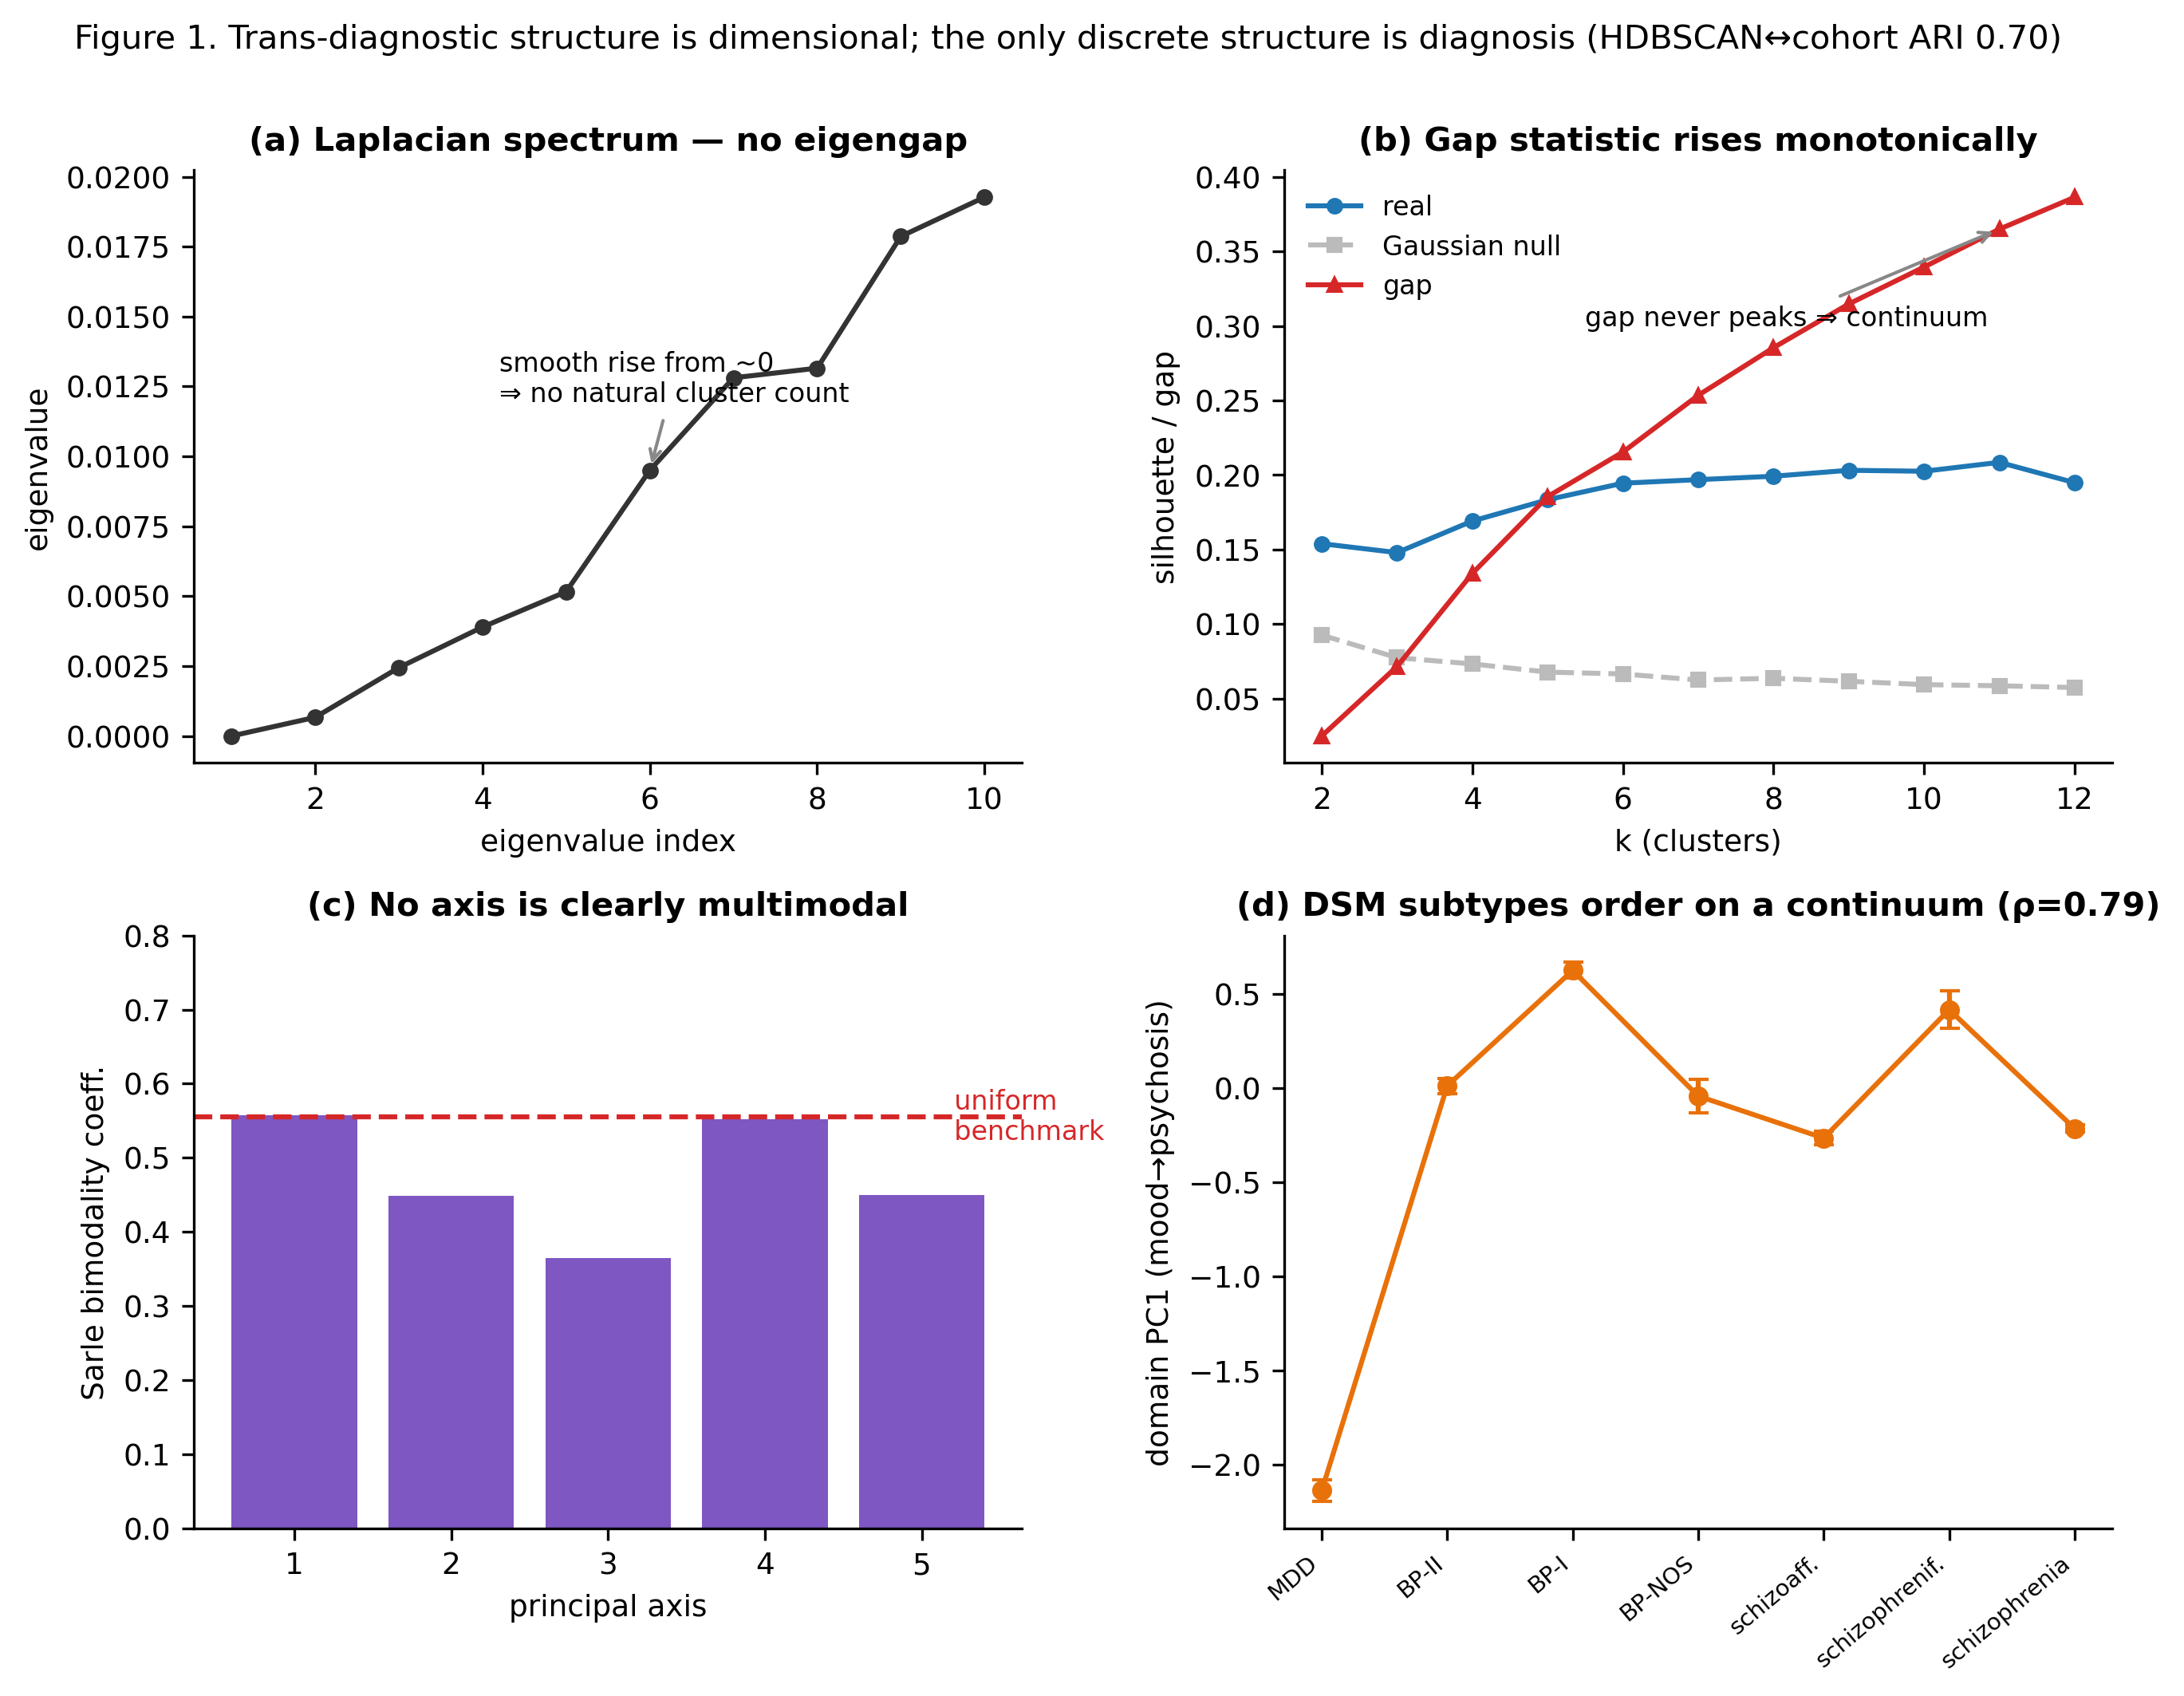

**Figure.** No eigengap; monotone gap; unimodal axes; HDBSCAN≈cohort; DSM mood↔psychosis continuum.

In [7]:
run_step("16_manuscript_figures.py")   # generates Figures 1–5 from the artifacts
fig("fig1_structure.png", "No eigengap; monotone gap; unimodal axes; HDBSCAN≈cohort; DSM mood↔psychosis continuum.")

## 5 · The six trans-diagnostic dimensions (§3.3)

We fit a **varimax factor model** on the standardized residual domains; the factor count is set by
**split-half Tucker congruence** (reproducibility), giving **K = 6**: depression/internalizing,
later age-of-onset, mania/activation, illness/hospitalization burden, metabolic/inflammatory load, and
ADHD/impulsivity/trauma. A **no-imputation masked autoencoder** recovers the same axes (canonical
correlations 0.93–0.63, far above a permutation null). The axes are confound-free (|corr| age/sex
≤0.002) and diagnosis-independent (cohort η²≤0.10, site ≤0.05).

In [8]:
run_step("05_dimensional_axes.py")     # classical varimax FA (AE reference)
run_step("06_dimensional_ae.py")       # masked autoencoder cross-check
run_step("07_dimensional_refine.py")   # LOCK K=6 by split-half congruence
fmeta = show("dimensional_final_meta.json")
print("locked K =", fmeta["K"], "| max |corr| age/sex =", max(fmeta["confound_max_corr"].values()))
ae = show("dimensional_ae_meta.json")
print("AE↔FA canonical correlations (top):", [round(x, 2) for x in ae["cca_with_classical_fa"][:6]])

$ python scripts/05_dimensional_axes.py 


  axis3 (var 1.8%) ↑: altman(+0.60); ymrs(+0.51); mathys(+0.47); psqi(+0.20); bis(+0.15); wurs(+0.12)
  axis4 (var 1.5%) ↑: nboccur_hospitalisation_lt(+0.64); hodur_hospitalisation_lt(+0.46); egf(−0.18); agedebut_hospitalisation(−0.18); isf(+0.14); edulevel(−0.13)
  axis5 (var 1.4%) ↑: wurs(+0.53); bis(+0.45); ctq(+0.31); suncf_cigarettes_lt(+0.14); ess(+0.13); edulevel(−0.13)
  axis6 (var 1.3%) ↑: metabolic_syndrome(+0.60); cholesterol(+0.37); inflammation(+0.27); hepatic(+0.23); edulevel(−0.13); fagers(+0.11)
  axis7 (var 0.7%) ↑: egf(+0.31); fast(−0.16); psqi(+0.16); madrs(−0.16); prism(+0.15); edulevel(+0.14)
  axis8 (var 0.5%) ↑: hooccur_arret_travail_actuel(+0.30); stprof(+0.26); hooccur_arret_travail(+0.22); maristat(+0.13); fast(+0.11); mars(+0.07)

mood↔psychosis continuum: best axis = axis8 (|Spearman| 0.71)
confound independence: max |corr| with age/sex across axes = 0.002
split-half Tucker congruence (per axis): [np.float64(1.0), np.float64(0.99), np.float64(0.99), np.float

masked AE: 9,013 patients × 54 domains → K=8 latent
  final masked recon MSE = 0.466
  mood↔psychosis continuum: best AE axis ae6 |Spearman|=0.89
  max |corr| AE axis vs age = 0.149
  canonical correlations AE vs classical FA: [0.93, 0.84, 0.8, 0.74, 0.63, 0.41, 0.28, 0.03] (high ⇒ same axes)

Wrote results/dimensional_ae_* + reports/dimensional_ae.html. Done.
$ python scripts/07_dimensional_refine.py 


final axes (top domains):
  axis1: qidsr(+0.72); madrs(+0.71); staya(+0.63); fast(+0.57); egf(-0.49)
  axis2: agetrt(+0.69); agedebutpremier_episode(+0.62); agedebut_hospitalisation(+0.49); nboccur_hospitalisation_lt(-0.17); isf(-0.09)
  axis3: altman(+0.59); ymrs(+0.54); mathys(+0.45); psqi(+0.18); bis(+0.17)
  axis4: nboccur_hospitalisation_lt(+0.60); hodur_hospitalisation_lt(+0.44); egf(-0.24); edulevel(-0.18); agedebut_hospitalisation(-0.16)
  axis5: metabolic_syndrome(+0.57); cholesterol(+0.38); inflammation(+0.27); hepatic(+0.23); suncf_cigarettes_lt(+0.12)
  axis6: wurs(+0.44); bis(+0.42); ctq(+0.23); prism(+0.16); ess(+0.16)

DSM-ordering by axis (subtype-centroid |Spearman|): [0.18, 0.32, 0.14, 0.36, 0.14, 0.11]; strongest = axis4 (0.36). The full mood↔psychosis spectrum is a direction across axes (AE recovers it at 0.89; not a single varimax factor).
confound: max |corr| age/sex across axes = 0.002

Wrote results/dimensional_final_* + reports/dimensional_final.html. Done.
loc

**Figure 2 — the six-dimension loading structure** (salient |λ|≥0.20).

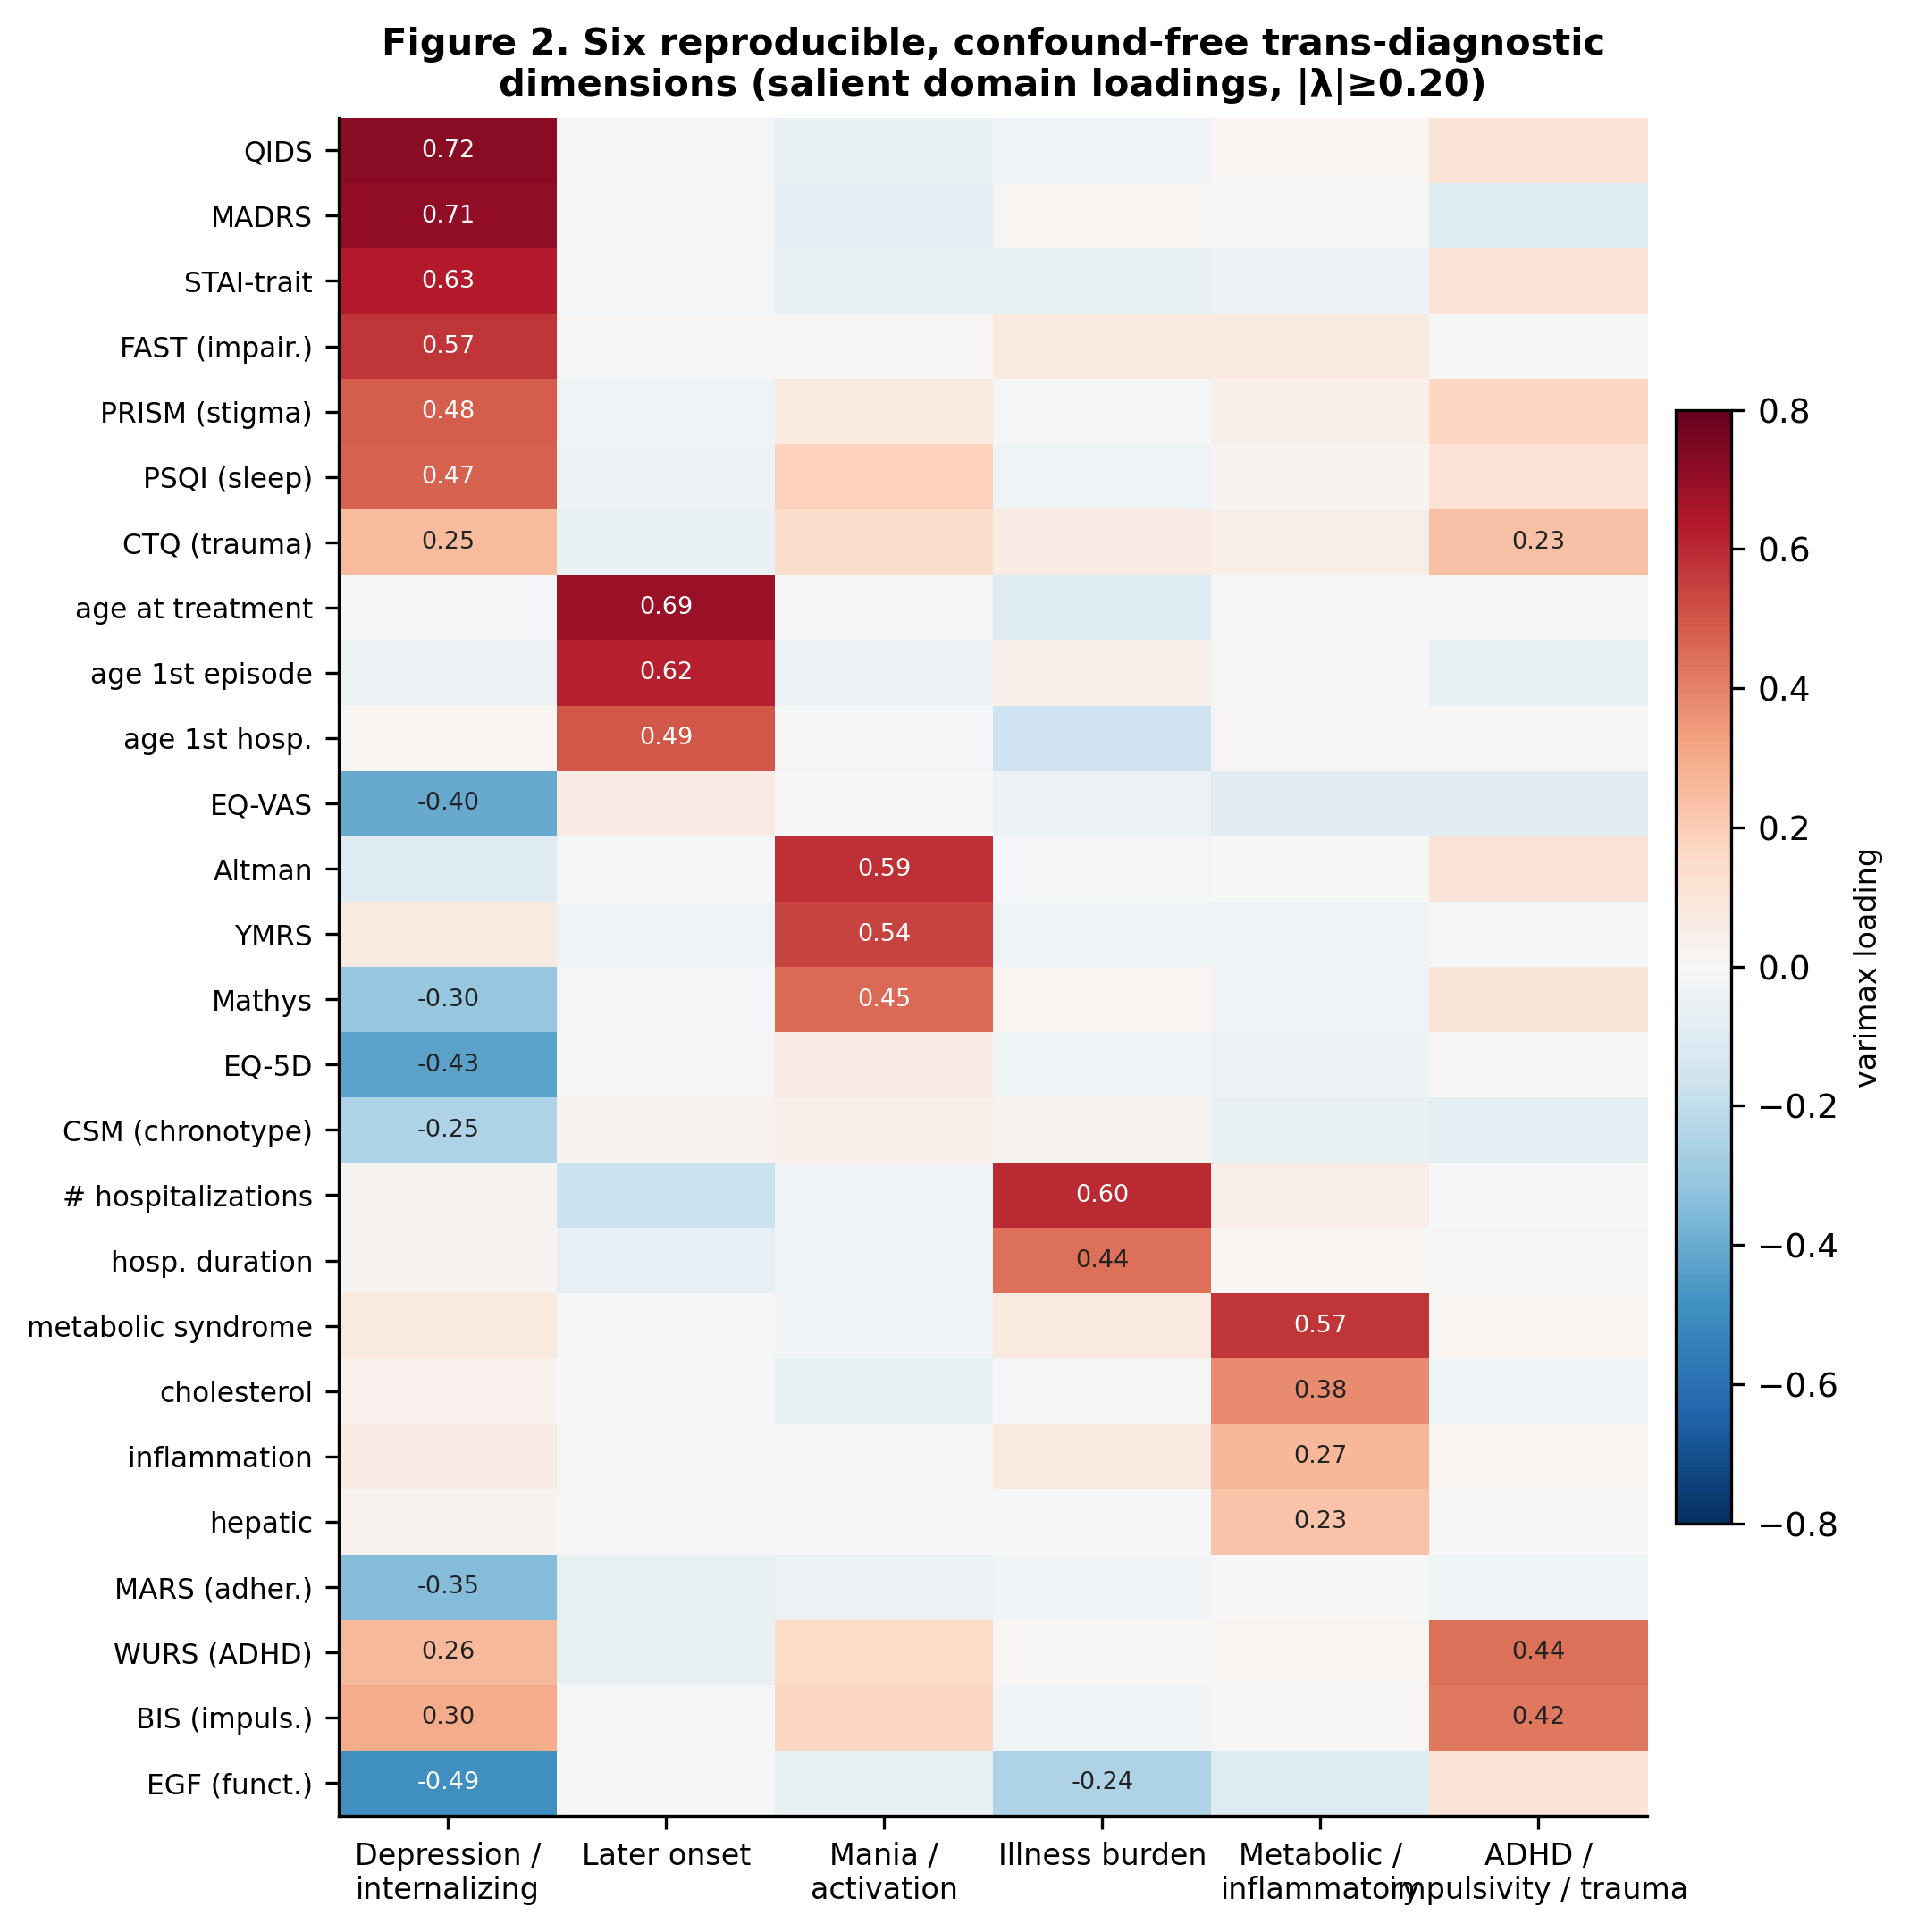

**Figure.** Clean block structure: each dimension is carried by a coherent set of instruments.

In [9]:
fig("fig2_loadings.png", "Clean block structure: each dimension is carried by a coherent set of instruments.")

Per-dimension reproducibility (split-half min Tucker congruence) and the K curve:

$ python scripts/15_review_checks.py 


#6 η²(cohort) max=0.103  η²(site) max=0.052
#7 CCA leading obs=0.93 vs permutation null mean=0.05 (95th pct 0.06)
#8 balanced-acc cohort from MASK=0.980, from embedding=1.000 (chance 0.333) ⇒ missingness DOES encode cohort
#9 mood↔psychosis |ρ|=0.79 (n=7 centroids) 95% CI [0.75, 0.857]
#5 wrote reports/figures/figS2_kcurve.png/.svg

Wrote results/review_checks.json
AE↔FA leading CCA: 0.935 vs permutation null 95th pct: 0.063
DSM-subtype variance explained per axis (eta^2): {'axis1': 0.103, 'axis2': 0.008, 'axis3': 0.006, 'axis4': 0.098, 'axis5': 0.009, 'axis6': 0.047}


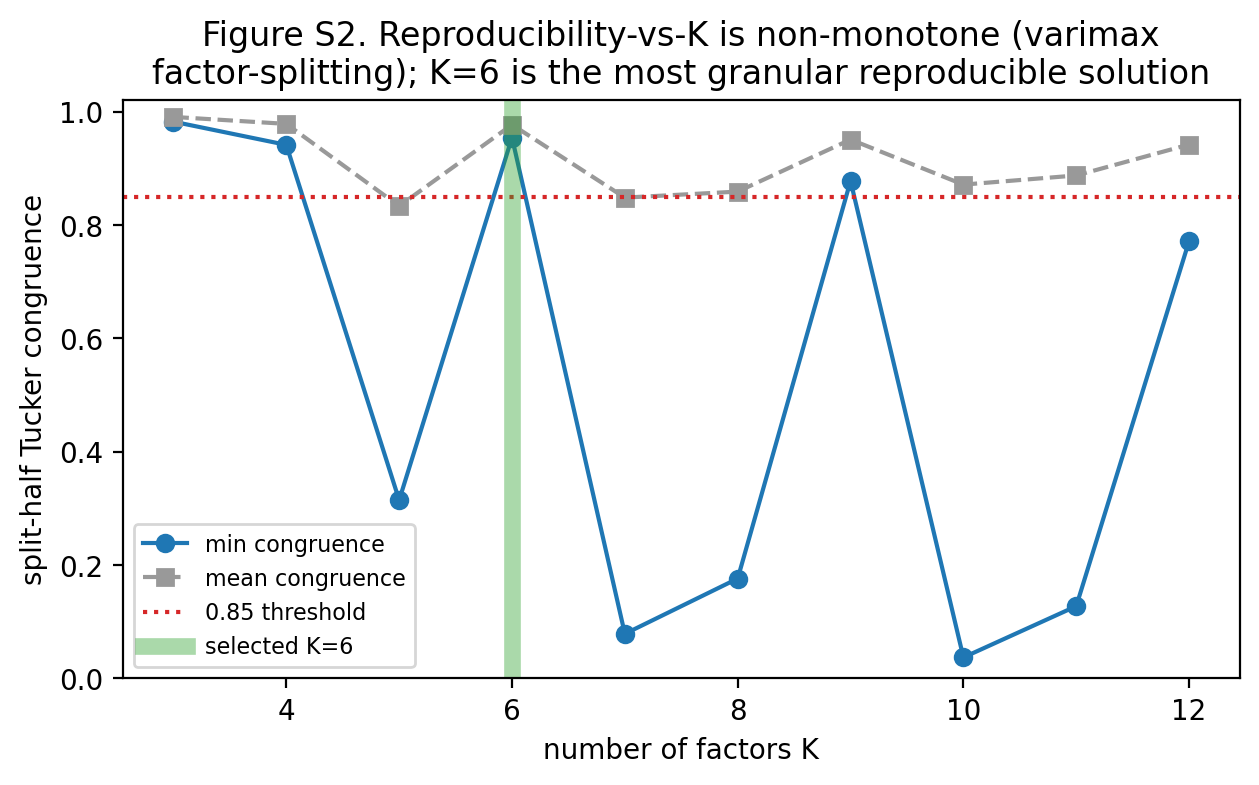

**Figure.** Reproducibility-vs-K is non-monotone; K=6 is the most granular reproducible solution.

In [10]:
run_step("15_review_checks.py")        # eta-squared (cohort/site), CCA permutation null, rho CI, figS2
rc = show("review_checks.json")
print("AE↔FA leading CCA:", rc["cca_observed"][0], "vs permutation null 95th pct:", rc["cca_null_leading_p95"])
print("DSM-subtype variance explained per axis (eta^2):", rc.get("eta_cohort"))
fig("figS2_kcurve.png", "Reproducibility-vs-K is non-monotone; K=6 is the most granular reproducible solution.")

**Figure 6c — trans-diagnostic overlap:** even the most diagnosis-linked axis (depression) is only ~14 % explained by DSM-5 (η²); diagnoses fan across the whole axis.

$ python scripts/18_export_dimensional_flow.py 


  ADHD/trauma    0.564
  wrote reports/figures/fig6_dimensional_flow.png/.svg
  wrote reports/figures/fig6b_band_persistence.png/.svg

Variance in each axis explained by DSM-5 subtype (η² [95% bootstrap CI], B=2000, n=9013):
  Depression     η²=0.145  [0.130, 0.160]
  Later onset    η²=0.010  [0.007, 0.016]
  Mania          η²=0.043  [0.036, 0.053]
  Illness burden η²=0.122  [0.109, 0.136]
  Metabolic      η²=0.010  [0.006, 0.015]
  ADHD/trauma    η²=0.019  [0.015, 0.026]
  wrote reports/figures/fig6c_dsm_axis_flow.png/.svg  (axis=depression_severity, η²=0.145)


,axis,eta_sq,ci_lo,ci_hi
0,depression_severity,0.144974,0.130383,0.160255
1,later_onset,0.010406,0.006778,0.016218
2,mania_activation,0.043396,0.035849,0.052570
3,illness_burden,0.121734,0.109142,0.136350
4,metabolic,0.009645,0.006163,0.014902
5,adhd_impulsivity_trauma,0.019264,0.014731,0.025906


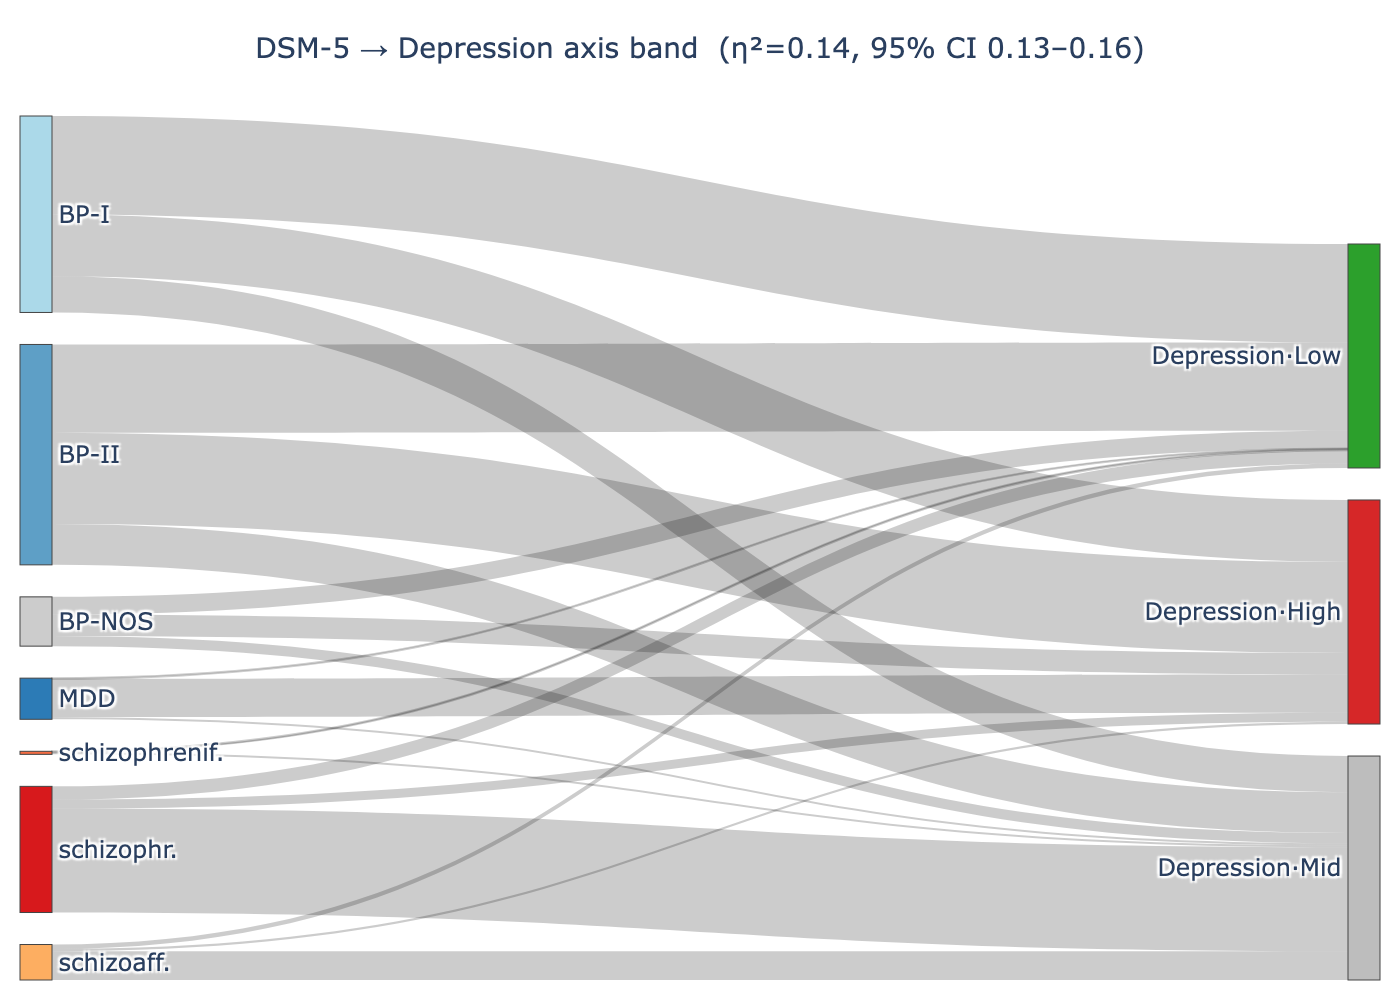

**Figure.** DSM-5 subtypes spread across Low/Mid/High of the depression axis (η²=0.14).

In [11]:
run_step("18_export_dimensional_flow.py")   # Figure 6 (a/b/c) + dimensional_dsm_eta_squared
display(show("dimensional_dsm_eta_squared.csv"))
fig("fig6c_dsm_axis_flow.png", "DSM-5 subtypes spread across Low/Mid/High of the depression axis (η²=0.14).")

## 6 · Temporal stability & the discrete-flow negative result (§3.6)

Projecting the locked axes onto follow-up visits gives a **trait↔state gradient**: ADHD/trauma is the
most trait-like (test–retest r 0.64), symptom axes more state-like. The **dimensional “flow”**
(continuous-axis band trajectories) shows a patient's *position* is largely retained, whereas forcing
**discrete** clusters gives labels that **hop** (~38 % persistence) and are independent of DSM-5
(ARI 0.006) — a *negative result* that motivates the dimensional model (Supplementary Figure S1).

In [12]:
run_step("08_longitudinal_axes.py")        # trait-state test-retest (Figure 4 data)
run_step("09_longitudinal_coherence.py")   # discrete-flow negative result + DSM contingency
display(show("longitudinal_axes_stability.csv").pivot(index="axis", columns="visit", values="pearson").round(2))
print("discrete clusters ↔ DSM-5 ARI:", show("longitudinal_meta.json").get("dsm_phenotype_ari"))

$ python scripts/08_longitudinal_axes.py 


  metabolic                V0↔Vk r = [0.2, 0.23, 0.19, 0.18]
  adhd_impulsivity_trauma  V0↔Vk r = [0.64, 0.6, 0.59, 0.56]

trait↔state gradient (mean V0↔V1/V2 r):
  adhd_impulsivity_trauma  0.62  TRAIT-like
  depression_severity      0.46  intermediate
  mania_activation         0.35  STATE-like
  illness_burden           0.29  STATE-like
  metabolic                0.22  STATE-like
  later_onset              0.06  STATE-like

Wrote results/longitudinal_axes_* + reports/longitudinal_axes.html. Done.
$ python scripts/09_longitudinal_coherence.py 



V0 phenotype classifier: 5-fold accuracy = 0.873 (8,858 V0 patients, k=5) — validity of the assignment rule
  V0→V1: n= 3782  ARI=0.069  persistence=38.8%
  V0→V2: n= 2612  ARI=0.070  persistence=38.7%
  V0→V3: n= 1739  ARI=0.061  persistence=37.5%
  V0→V4: n=  697  ARI=0.065  persistence=37.3%

per-phenotype persistence V0→V1: {0: 0.4, 1: 0.59, 2: 0.48, 3: 0.35, 4: 0.14}

DSM-5 subtype ↔ V0 phenotype ARI = 0.006 (≈0 ⇒ phenotypes cut across DSM-5; the flow is trans-diagnostic)

Wrote results/longitudinal_* and reports/longitudinal.html. Done.


visit,V1,V2,V3,V4
axis,,,,
adhd_impulsivity_trauma,0.64,0.60,0.59,0.56
depression_severity,0.49,0.43,0.37,0.34
illness_burden,0.30,0.28,0.26,0.20
later_onset,0.08,0.04,0.07,0.09
mania_activation,0.35,0.34,0.34,0.26
metabolic,0.20,0.23,0.19,0.18


discrete clusters ↔ DSM-5 ARI: 0.006081029890253045


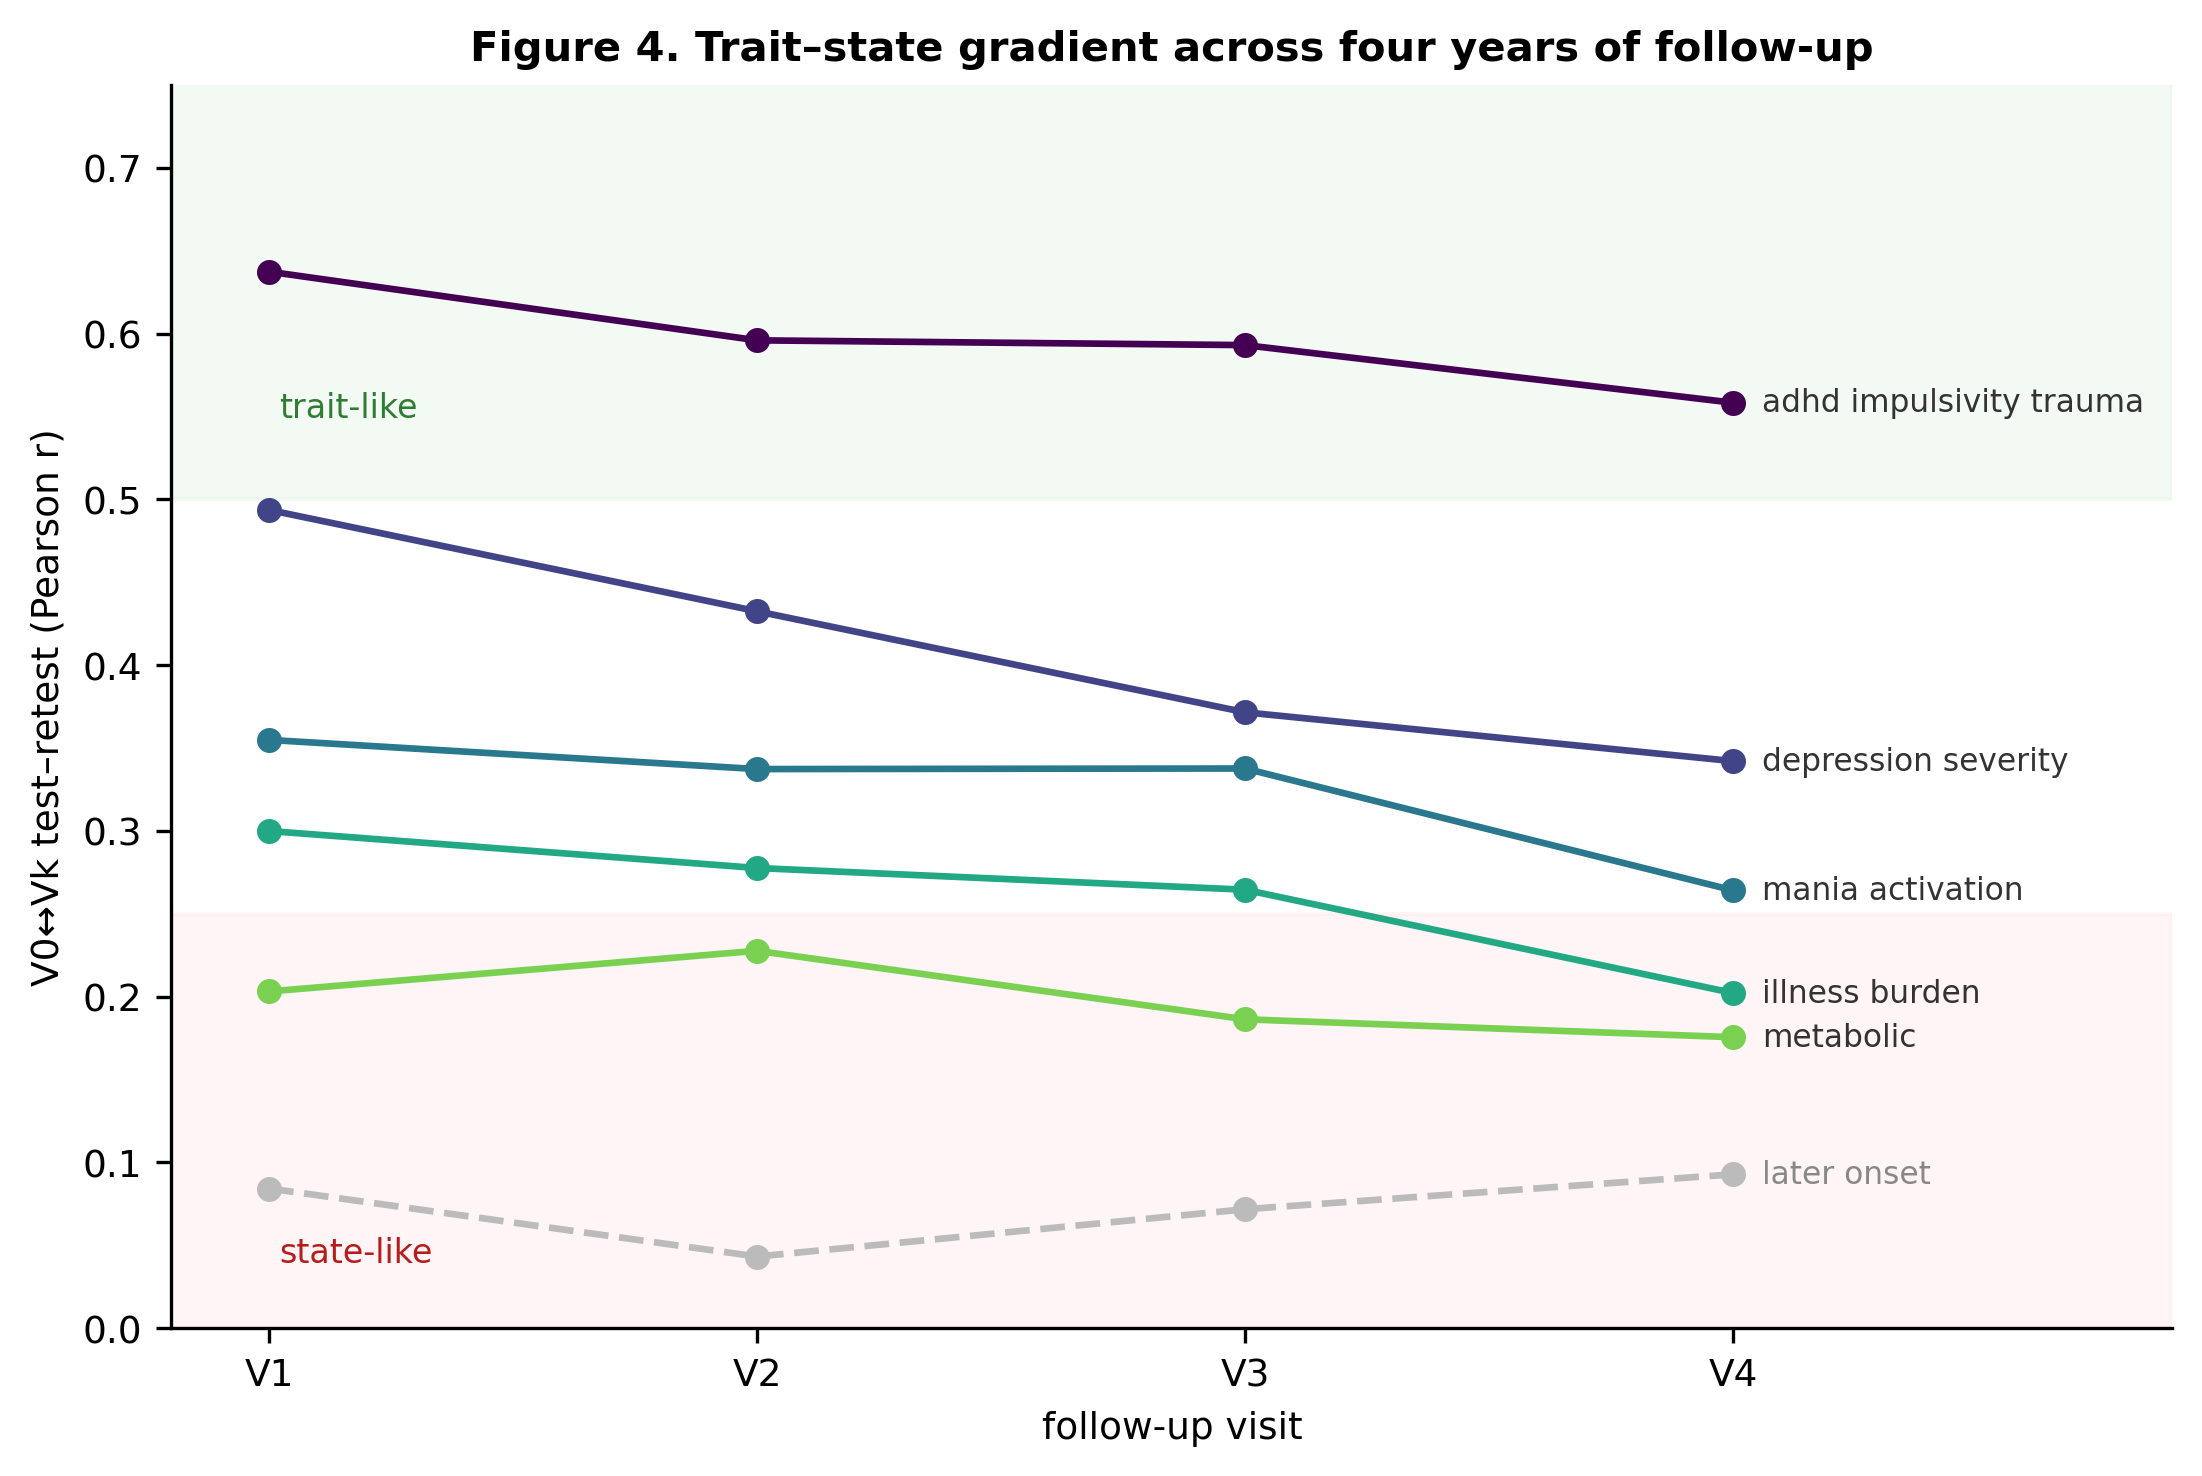

**Figure.** Trait–state gradient across V1–V4 (ADHD/trauma trait-like; later-onset static).

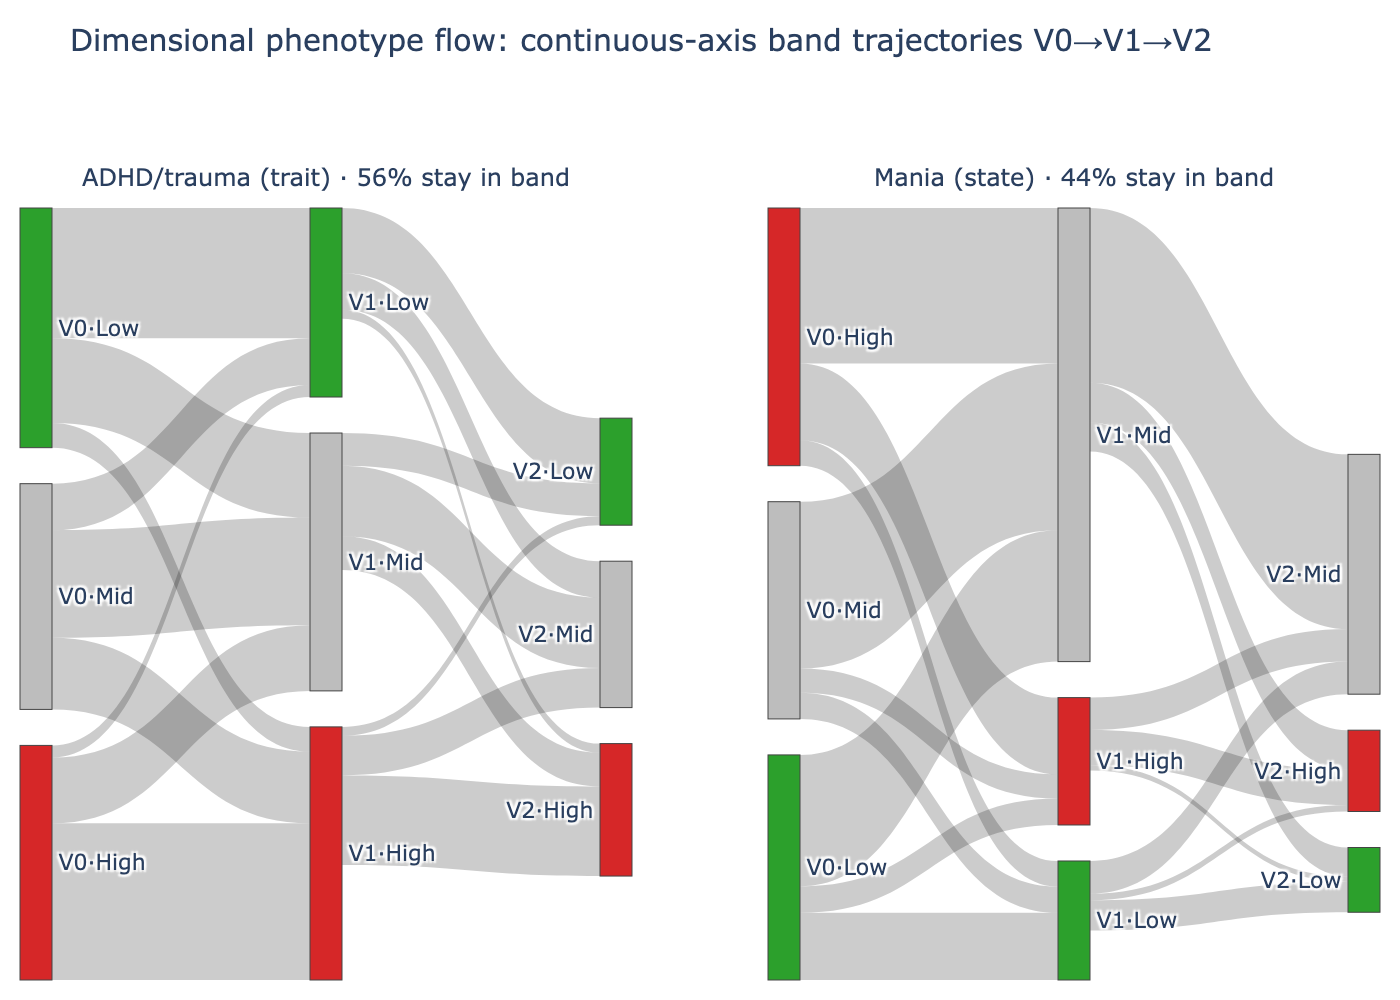

**Figure.** Dimensional flow: continuous-axis band trajectories V0→V1→V2 (positions retained).

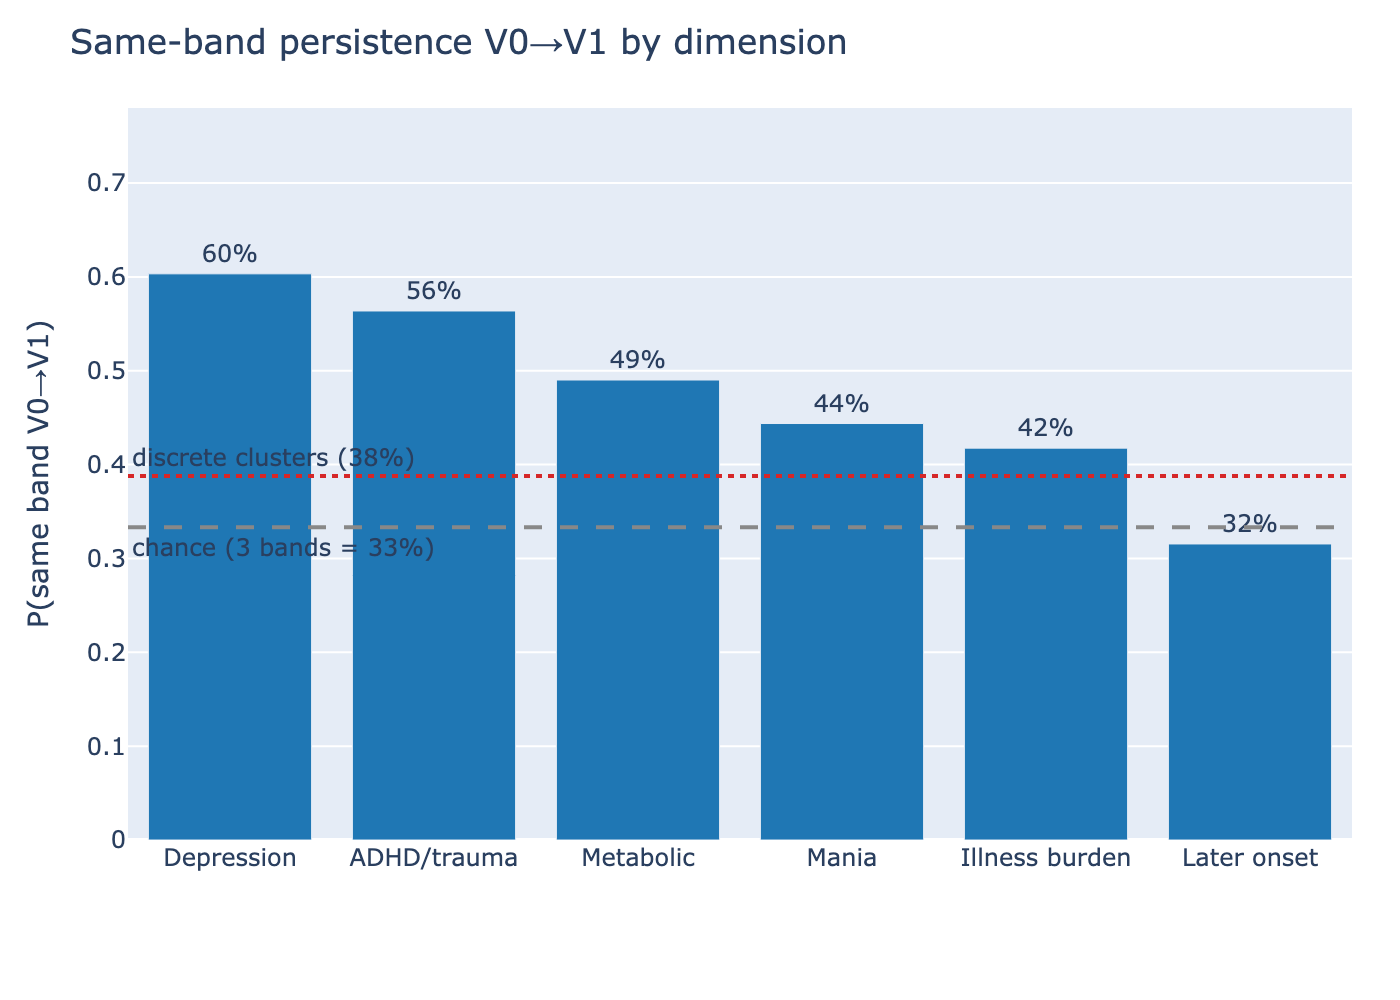

**Figure.** Same-band persistence per dimension vs chance (33%) and the discrete clusters' 38%.

$ python scripts/17_export_longitudinal_figure.py 


  wrote reports/figures/figS1_dsm_phenotype_flow.png/.svg  (ARI=0.006)
  wrote reports/figures/figS1b_dsm_composition.png/.svg


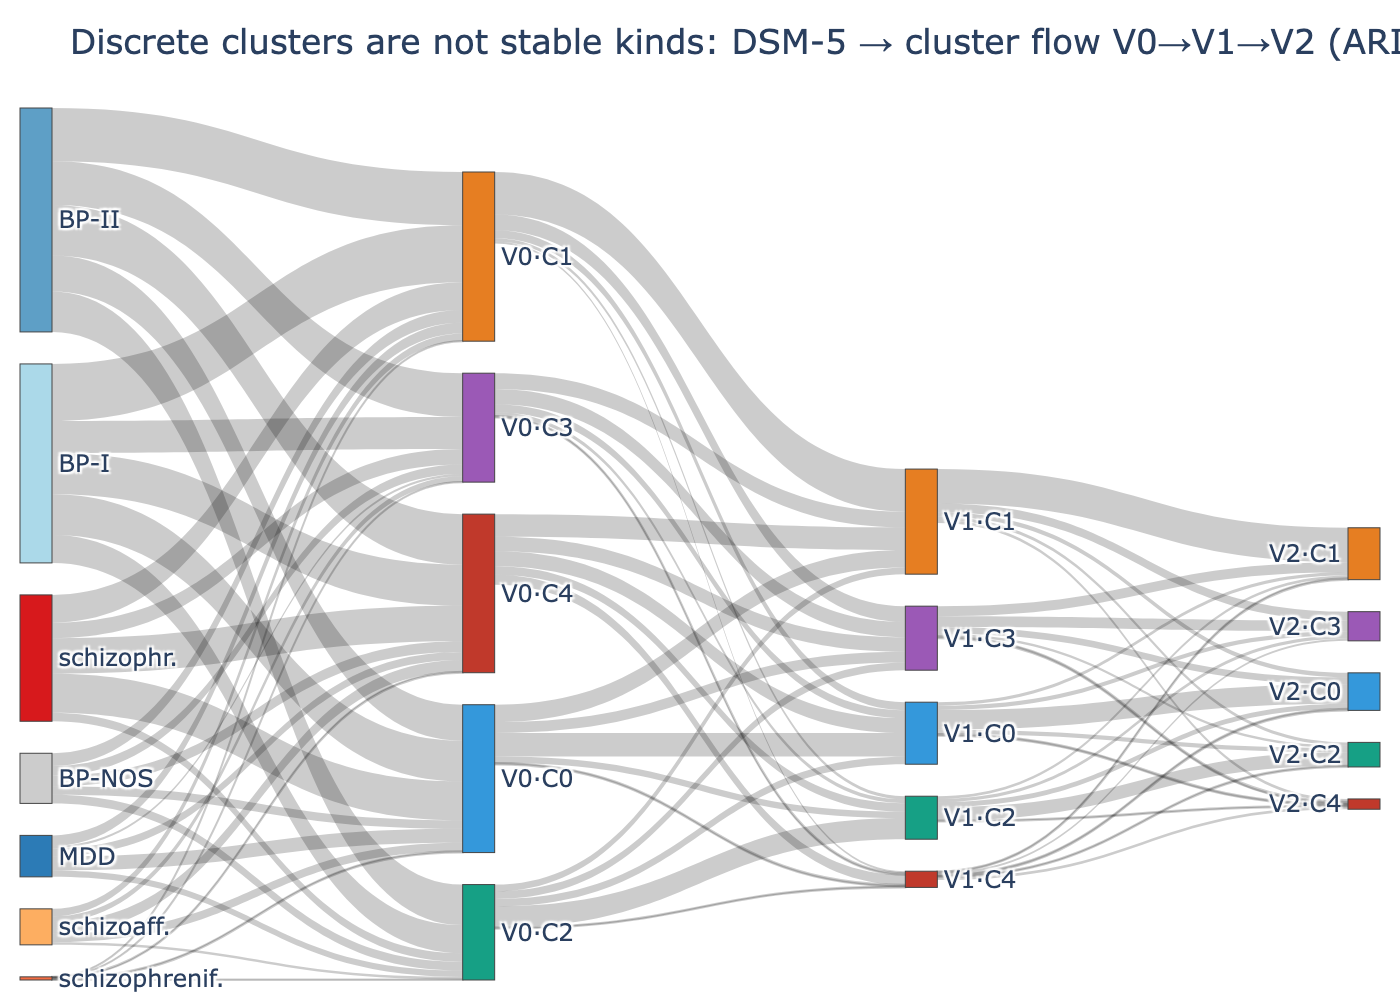

**Figure.** Suppl. S1 — discrete clusters: trans-diagnostic (ARI 0.006) and temporally fluid.

In [13]:
fig("fig4_traitstate.png", "Trait–state gradient across V1–V4 (ADHD/trauma trait-like; later-onset static).")
fig("fig6_dimensional_flow.png", "Dimensional flow: continuous-axis band trajectories V0→V1→V2 (positions retained).")
fig("fig6b_band_persistence.png", "Same-band persistence per dimension vs chance (33%) and the discrete clusters' 38%.")
run_step("17_export_longitudinal_figure.py")   # Supplementary Figure S1 (discrete flow)
fig("figS1_dsm_phenotype_flow.png", "Suppl. S1 — discrete clusters: trans-diagnostic (ARI 0.006) and temporally fluid.")

## 7 · Do the dimensions beat DSM diagnosis? (the value test — §3.4–3.5)

Leakage-safe, **shuffled** nested 5-fold CV predicting 1-year outcomes from V0 (baseline + age + sex
adjusted): the dimensions **outperform** DSM for quality of life and **complement** it for functioning;
DSM + prior service use dominate hospitalization. Confidence intervals come from repeated CV; the
advantage survives **de-circularization** (refit axes without each outcome's own measure), **ComBat**
site harmonization, and a second follow-up (V2, same cohort).

In [14]:
run_step("10_phase5_outcomes.py", "--visit", "V1")
run_step("10_phase5_outcomes.py", "--visit", "V2")
run_step("11_phase5_ci.py")                 # repeated-CV 95% intervals
run_step("12_phase5_decircularized.py")     # de-circularization sensitivity
run_step("13_robustness_site.py")           # ComBat
print("V1 head-to-head:"); display(show("phase5_headtohead_V1.csv"))
print("Repeated-CV 95% intervals on the differences:"); display(show("phase5_ci.csv"))
print("De-circularized (axes refit w/o each outcome's own measures):"); display(show("phase5_decircularized.csv"))

$ python scripts/10_phase5_outcomes.py --visit V1


EGF functioning: n=3196 R2  DSM=0.366  axes=0.361  combined=0.392  (axes−DSM -0.004; added-axes p=1.1e-16)
any hospitalization: n=3332 AUC  DSM=0.743  axes=0.600  combined=0.752  (axes−DSM -0.143; added-axes p=nan)
EQ-5D quality of life: n=2423 R2  DSM=0.305  axes=0.341  combined=0.343  (axes−DSM +0.036; added-axes p=1.1e-16)

Wrote results/phase5_* + reports/phase5.html. Done.
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
$ python scripts/10_phase5_outcomes.py --visit V2


EGF functioning: n=2121 R2  DSM=0.306  axes=0.312  combined=0.353  (axes−DSM +0.006; added-axes p=1.1e-16)
any hospitalization: n=2371 AUC  DSM=0.727  axes=0.601  combined=0.725  (axes−DSM -0.126; added-axes p=5.0e-03)
EQ-5D quality of life: n=1561 R2  DSM=0.230  axes=0.265  combined=0.267  (axes−DSM +0.034; added-axes p=1.1e-16)

Wrote results/phase5_* + reports/phase5.html. Done.
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
$ python scripts/11_phase5_ci.py 


EQ-5D quality of life: n=2423 R2  DSM=0.302[0.295,0.306]  axes=0.339[0.332,0.343]  Δdim−DSM=+0.036[+0.033,+0.039]  Δcomb−DSM=+0.039[+0.036,+0.041]
EGF functioning: n=3196 R2  DSM=0.365[0.362,0.367]  axes=0.362[0.359,0.365]  Δdim−DSM=-0.003[-0.005,-0.001]  Δcomb−DSM=+0.029[+0.027,+0.030]
any hospitalization: n=3332 AUC  DSM=0.747[0.741,0.752]  axes=0.604[0.588,0.618]  Δdim−DSM=-0.143[-0.158,-0.130]  Δcomb−DSM=+0.011[+0.004,+0.016]

Wrote results/phase5_ci.csv (R=200 repeats)
$ python scripts/12_phase5_decircularized.py 


EQ-5D quality of life: n=2423 R2  DSM=0.305 | axes_full=0.341 (Δ+0.036) → axes_clean=0.340 (Δ+0.036) | combined_clean=0.343 (Δ+0.038)   [drop ['eq5d', 'eq']]
EGF functioning: n=3196 R2  DSM=0.366 | axes_full=0.361 (Δ-0.004) → axes_clean=0.361 (Δ-0.005) | combined_clean=0.392 (Δ+0.026)   [drop ['egf', 'fast']]
any hospitalization: n=3332 AUC  DSM=0.743 | axes_full=0.600 (Δ-0.143) → axes_clean=0.600 (Δ-0.143) | combined_clean=0.759 (Δ+0.016)   [drop ['nboccur_hospitalisation_lt', 'hodur_hospitalisation_lt']]

Wrote results/phase5_decircularized.csv
$ python scripts/13_robustness_site.py 


...

,outcome,n,metric,DSM,axes,combined,axes_minus_DSM,added_axes_p
0,EGF functioning,3196,R2,0.366,0.361,0.392,-0.004,1.110223e-16
1,any hospitalization,3332,AUC,0.743,0.600,0.752,-0.143,NaN
2,EQ-5D quality of life,2423,R2,0.305,0.341,0.343,0.036,1.110223e-16


Repeated-CV 95% intervals on the differences:


,outcome,n,metric,DSM,axes,combined,dim_minus_DSM,combined_minus_DSM,dim>DSM_excludes_0
0,EQ-5D quality of life,2423,R2,"0.302 [0.295,0.306]","0.339 [0.332,0.343]","0.341 [0.334,0.346]","+0.036 [+0.033,+0.039]","+0.039 [+0.036,+0.041]",True
1,EGF functioning,3196,R2,"0.365 [0.362,0.367]","0.362 [0.359,0.365]","0.394 [0.390,0.397]","-0.003 [-0.005,-0.001]","+0.029 [+0.027,+0.030]",True
2,any hospitalization,3332,AUC,"0.747 [0.741,0.752]","0.604 [0.588,0.618]","0.758 [0.749,0.765]","-0.143 [-0.158,-0.130]","+0.011 [+0.004,+0.016]",True


De-circularized (axes refit w/o each outcome's own measures):


,outcome,n,metric,excluded,DSM,axes_full,axes_clean,combined_clean,full_minus_DSM,clean_minus_DSM,combined_minus_DSM
0,EQ-5D quality of life,2423,R2,eq5d+eq,0.305,0.341,0.340,0.343,0.036,0.036,0.038
1,EGF functioning,3196,R2,egf+fast,0.366,0.361,0.361,0.392,-0.004,-0.005,0.026
2,any hospitalization,3332,AUC,nboccur_hospitalisation_lt+hodur_hospitalisati...,0.743,0.600,0.600,0.759,-0.143,-0.143,0.016


**Figure 3 — head-to-head outcome prediction** (DSM vs dimensions vs combined; V1 + V2).

$ python scripts/16_manuscript_figures.py 


generating manuscript figures → /Users/andriikulakovskyi/Desktop/face-common-bp-sz-dr/reports/figures
  wrote reports/figures/fig2_loadings.png + .svg
  wrote reports/figures/fig3_headtohead.png + .svg
  wrote reports/figures/fig4_traitstate.png + .svg
  wrote reports/figures/fig5_cognition.png + .svg
  wrote reports/figures/fig1_structure.png + .svg
done.


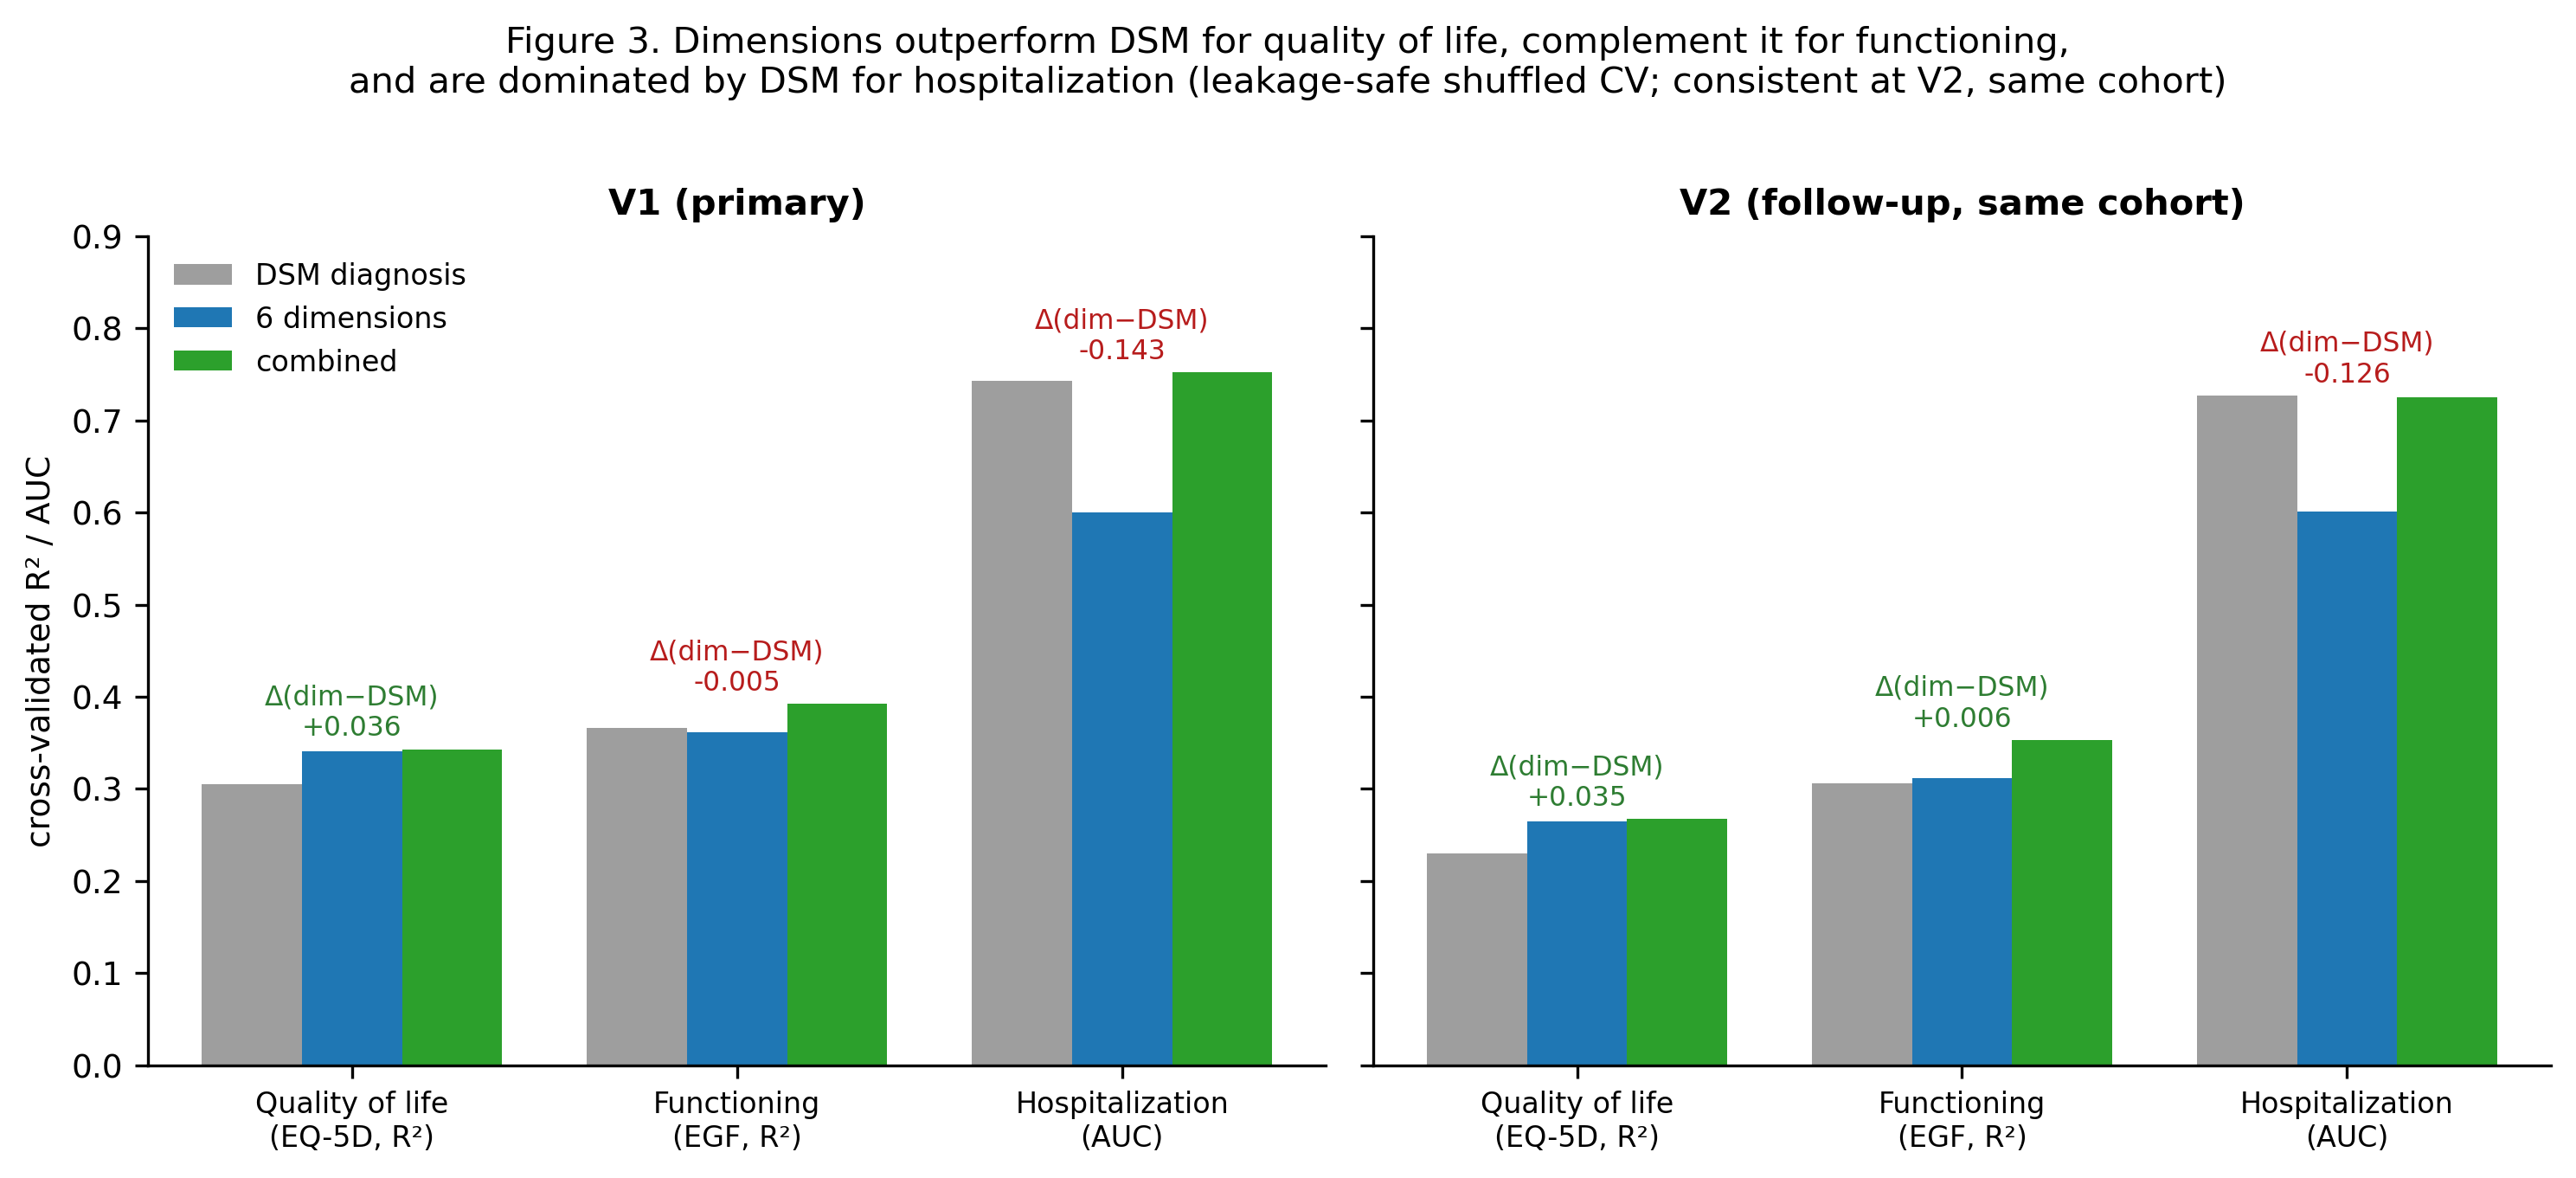

**Figure.** QoL: dimensions beat DSM; functioning: combined wins; hospitalization: DSM dominates.

In [15]:
run_step("16_manuscript_figures.py")   # refresh Fig 3 with the latest head-to-head numbers
fig("fig3_headtohead.png", "QoL: dimensions beat DSM; functioning: combined wins; hospitalization: DSM dominates.")

## 8 · Cognition (BP/SZ complementary analysis — §3.7)

Neuropsychology is absent in DR by design, so cognition is analysed within BP/SZ only. It resolves into
the classic **general-ability (g) + processing-speed** structure, is semi-independent of the symptom
dimensions (max |r| 0.24, g↔illness-burden), and adds a small independent increment to functioning.

$ python scripts/14_cognition_bpsz.py 


cognitive factors (K=2, parallel analysis):
  cog1: percept_reasoning(+0.67); working_memory(+0.59); verbal_reasoning(+0.47); memory_cvlt(+0.41); fluency(+0.26)
  cog2: proc_speed(+0.80); executive_tmt(-0.22); fluency(+0.17); memory_cvlt(+0.11); percept_reasoning(+0.09)

cognition ↔ symptom-axis correlations (n=6,099 BP/SZ):
      depression_severity  later_onset  mania_activation  illness_burden  metabolic  adhd_impulsivity_trauma
cog1               -0.130        0.013            -0.034          -0.241     -0.155                   -0.064
cog2               -0.103        0.027             0.023          -0.064     -0.038                    0.016

V1 functioning (EGF), n=2,478 BP/SZ:  symptom-axes R²=0.394  +cognition R²=0.398  (Δ +0.004)

Wrote results/cognition_bpsz_* + reports/cognition_bpsz.html. Done.
cognition subset n=6099 {'bp': 4273, 'sz': 1826} | K=2 factors
cognition × symptom-axis correlations (max |r| ≈ 0.24):


,depression_severity,later_onset,mania_activation,illness_burden,metabolic,adhd_impulsivity_trauma
cog1,-0.13,0.01,-0.03,-0.24,-0.15,-0.06
cog2,-0.10,0.03,0.02,-0.06,-0.04,0.02


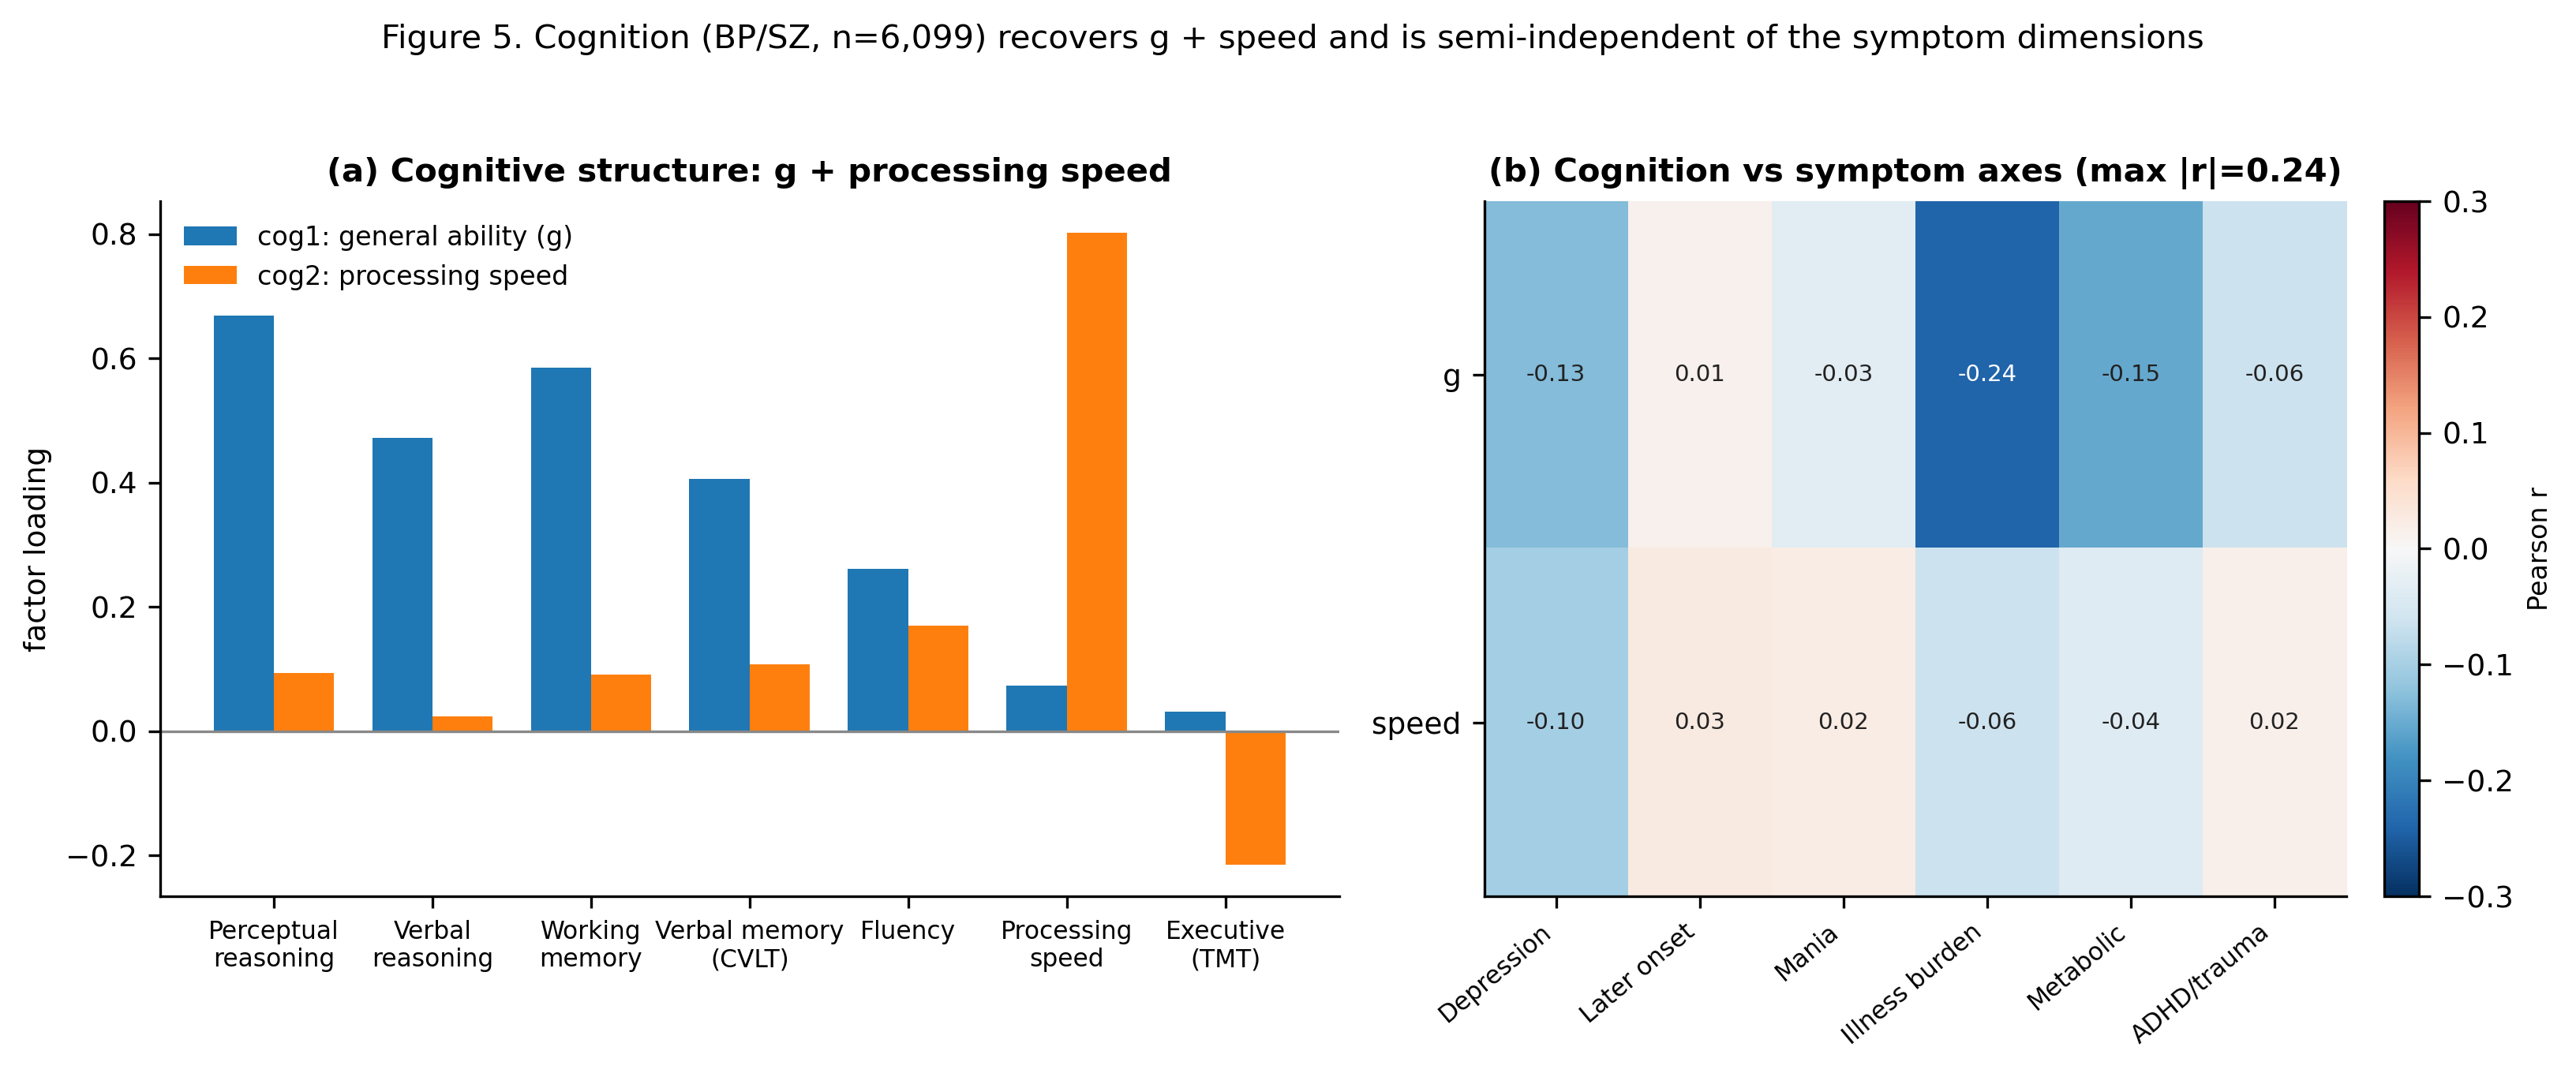

**Figure.** g + processing-speed structure; semi-independent of the symptom dimensions.

In [16]:
run_step("14_cognition_bpsz.py")
cm = show("cognition_bpsz_meta.json")
print(f"cognition subset n={cm['n_cognition']} {cm['cohort']} | K={cm['K']} factors")
print("cognition × symptom-axis correlations (max |r| ≈ 0.24):"); display(show("cognition_bpsz_corr.csv", index_col=0).round(2))
fig("fig5_cognition.png", "g + processing-speed structure; semi-independent of the symptom dimensions.")

## 9 · Summary

| Claim | Evidence (reproduced above) |
|---|---|
| Structure is **dimensional, not categorical** | no eigengap · monotone gap · HDBSCAN≈cohort · DSM continuum ρ 0.79 |
| **Six** reproducible, confound-free axes | split-half congruence ≥0.95 · age/sex |corr|≤0.002 · FA≈AE (CCA 0.93 vs null 0.06) |
| Genuinely **trans-diagnostic** | cohort η²≤0.10, site ≤0.05; even depression axis only η²0.14 of DSM |
| Axes **beat/complement DSM** for patient-reported outcomes | QoL +0.036 [+0.033,+0.039]; functioning combined +0.029; robust to de-circularization, ComBat, V2 |
| Discrete clustering **fails** | ~38 % persistence, DSM-ARI 0.006 → slices of a continuum (Suppl. S1) |
| Cognition = **g + speed**, semi-independent | max |r| 0.24 |

Everything above is regenerated from the raw data by the scripts in `scripts/` (orchestrated by
`scripts/00_run_all.py`). Full prose, methods and references: **`MANUSCRIPT.md`**.